 ## Post-Processing of OGV_RANS

### About

Main routine for OGV_RANS

October 2024

### Initialization 

In [69]:
# Import librairies and classes
import numpy                    as np
import matplotlib.pyplot        as plt
import matplotlib.font_manager  as font_manager
import pandas                   as pd
import math 
import os

from mod_postProcessMusicaa     import postProcess
from matplotlib                 import colors
from mpl_toolkits.mplot3d       import Axes3D
from matplotlib.animation       import FuncAnimation
from matplotlib.colors          import LinearSegmentedColormap
from matplotlib.colors          import LogNorm
from matplotlib.colors          import TwoSlopeNorm
from IPython.display            import HTML

## Auto-reload of all changes in the imported scripts 
%load_ext autoreload
%autoreload 2

## Ensures inline plot 
%matplotlib inline 

## Add option to toggle on/off raw code 
from IPython.display import HTML

HTML('''<script>
code_show=true; 
function code_toggle() {
 if (code_show){
 $('div.input').hide();
 } else {
 $('div.input').show();
 }
 code_show = !code_show
} 
$( document ).ready(code_toggle);
</script>
<form action="javascript:code_toggle()"><input type="submit" value="Click here to toggle on/off the raw code."></form>''')

## Initialization of class 

#repo    = "../OGV_RANS_20241007_kOmegaSST"
repo    = "../Spalart_Allmaras/with_transition_model/OGV_RANS_20250113/OGV_RANS_202501113_noShock"
pp_OGV_RANS = postProcess(rep=repo,bloc=[3,4,6,7], bloc_fst=[1,2,3,4,5,6,7,8,9], is_2D=True, ngh=5, is_RANS=True, model_RANS = 'SA' ,is_extended=True, is_stats=True, is_little_endian=True)
pp_OGV_RANS.init_postProcess()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
*======
Reading info.ini
Done reading info.ini
*======
Reading info.ini
Done reading info.ini
*======
Reading time.ini
Done reading time.ini
*======
Reading param_blocks.ini
Done reading param_blocks.ini
*======
Reading grid
ngk is: 1
Block #1, Mesh size: nx = 75, ny = 25, nz = 1
ngk is: 1
Block #2, Mesh size: nx = 75, ny = 50, nz = 1
ngk is: 1
Block #3, Mesh size: nx = 25, ny = 50, nz = 1
ngk is: 1
Block #4, Mesh size: nx = 100, ny = 50, nz = 1
ngk is: 1
Block #5, Mesh size: nx = 100, ny = 50, nz = 1
ngk is: 1
Block #6, Mesh size: nx = 100, ny = 50, nz = 1
ngk is: 1
Block #7, Mesh size: nx = 50, ny = 50, nz = 1
ngk is: 1
Block #8, Mesh size: nx = 75, ny = 50, nz = 1
ngk is: 1
Block #9, Mesh size: nx = 75, ny = 50, nz = 1
*======
Read snapshot characteristics
Done reading snapshot characteristics
*======
Reading stats from block 1 in files ../Spalart_Allmaras/with_transition_model/OGV_RANS_20250113/

### Read Grid

In [70]:
pitch = pp_OGV_RANS.y[2][1][-1] - pp_OGV_RANS.y[1][1][0]
pitch2 = pp_OGV_RANS.y[9][1][-1] - pp_OGV_RANS.y[8][1][0]
pitch = pitch
#pitch = pitch*1.01 #Need to find out why you need a factor 
print(pitch)
print(pitch2)

39.84483736055724
39.7348845081429


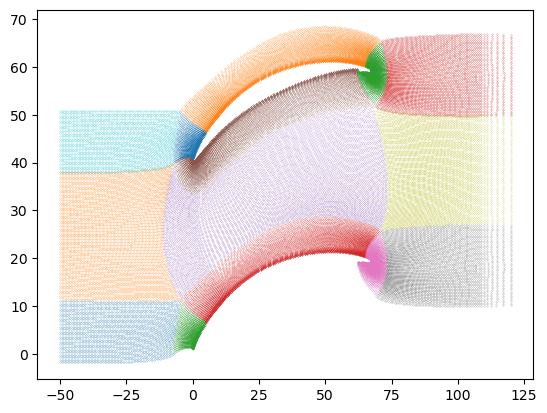

In [71]:
size = 0.02

for i in range(1,10):
    x_i = pp_OGV_RANS.x[i]
    y_i = pp_OGV_RANS.y[i]
    
    x_i_flat = x_i.flatten()
    y_i_flat = y_i.flatten()
    plt.scatter(x_i_flat,y_i_flat,s=size)

for i in [1,3,4,7,8]:
    x_i_up=pp_OGV_RANS.x[i]
    y_i_up=pp_OGV_RANS.y[i]+pitch
    x_i_up_flat = x_i_up.flatten()
    y_i_up_flat = y_i_up.flatten()
    plt.scatter(x_i_up_flat,y_i_up_flat,s=size)

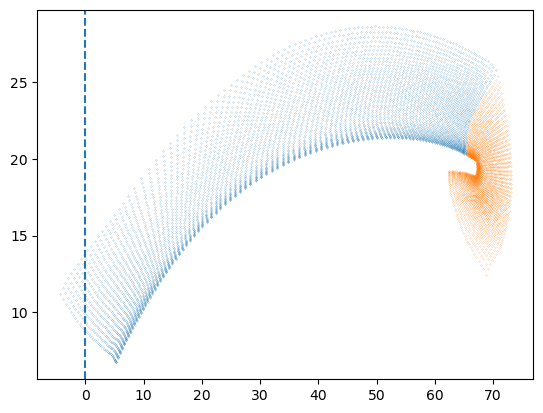

In [72]:
#for i in [2,5,6,9]:
for i in [4,7]:
    x_i=pp_OGV_RANS.x[i]
    y_i=pp_OGV_RANS.y[i]
    x_i_flat = x_i.flatten()
    y_i_flat = y_i.flatten()
    plt.scatter(x_i_flat,y_i_flat,s=size)
    
plt.axvline(x=0, linestyle='--')

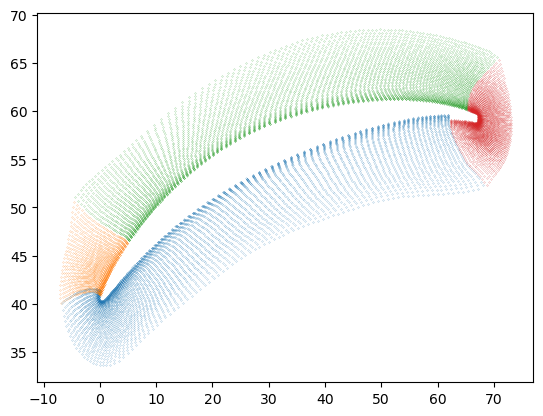

In [73]:
for i in [6]:
    x_i = pp_OGV_RANS.x[i]
    y_i = pp_OGV_RANS.y[i]
    
    x_i_flat = x_i.flatten()
    y_i_flat = y_i.flatten()
    plt.scatter(x_i_flat,y_i_flat,s=size)

for i in [3,4,7]:
    x_i_up=pp_OGV_RANS.x[i]
    y_i_up=pp_OGV_RANS.y[i]+pitch
    x_i_up_flat = x_i_up.flatten()
    y_i_up_flat = y_i_up.flatten()
    plt.scatter(x_i_up_flat,y_i_up_flat,s=size)

### Reynolds Number

/tmp/ipykernel_11042/850693487.py:17: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(x_i,y_i,Re_i,vmin=vmin,vmax=vmax)


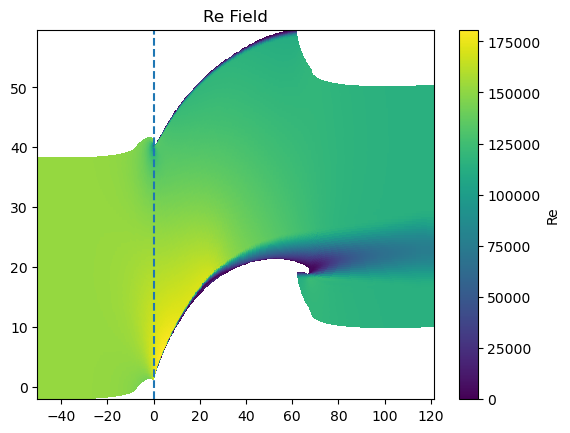

In [74]:
vmins = []
vmaxs = []
l_ref= 0.07

for i in range(1,10):
    Re_i = pp_OGV_RANS._stats1[i]['rho'] * np.sqrt(pp_OGV_RANS._stats1[i]['u']**2 + pp_OGV_RANS._stats1[i]['v']**2 + pp_OGV_RANS._stats1[i]['w']**2)*l_ref/pp_OGV_RANS._stats1[i]['mu']
    vmins.append(Re_i.min())
    vmaxs.append(Re_i.max())
    
vmin = min(vmins)
vmax = max(vmaxs)
    
for i in range(1,10):
    x_i=pp_OGV_RANS.x[i]
    y_i=pp_OGV_RANS.y[i]
    Re_i = pp_OGV_RANS._stats1[i]['rho'] * np.sqrt(pp_OGV_RANS._stats1[i]['u']**2 + pp_OGV_RANS._stats1[i]['v']**2 + pp_OGV_RANS._stats1[i]['w']**2)*l_ref/pp_OGV_RANS._stats1[i]['mu']
    plt.pcolormesh(x_i,y_i,Re_i,vmin=vmin,vmax=vmax)
#    #contours = plt.contour(x_i,y_i,pres_i)
    
plt.title('Re Field')
plt.colorbar(label='Re')
plt.axvline(x=0, linestyle='--')

### Pressure field

/tmp/ipykernel_11042/4251221480.py:16: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(x_i,y_i,pres_i,vmin=vmin,vmax=vmax)


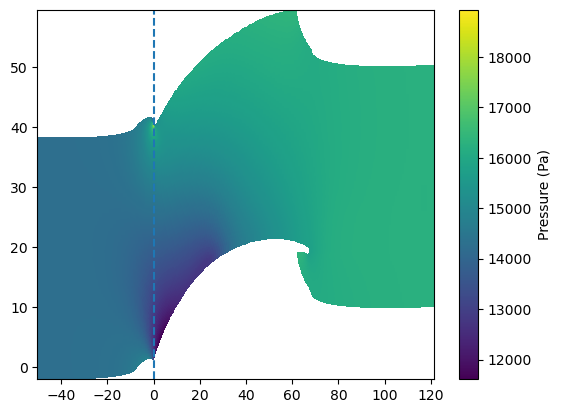

In [75]:
vmins = []
vmaxs = []

for i in range(1,10):
    pres_i = pp_OGV_RANS._stats1[i]['p']
    vmins.append(pres_i.min())
    vmaxs.append(pres_i.max())
    
vmin = min(vmins)
vmax = max(vmaxs)
    
for i in range(1,10):
    x_i=pp_OGV_RANS.x[i]
    y_i=pp_OGV_RANS.y[i]
    pres_i = pp_OGV_RANS._stats1[i]['p']
    plt.pcolormesh(x_i,y_i,pres_i,vmin=vmin,vmax=vmax)
    #plt.pcolormesh(x_i,y_i,pres_i,vmin=15000,vmax=16000)
    #contours = plt.contour(x_i,y_i,pres_i)
    
plt.colorbar(label='Pressure (Pa)')
plt.axvline(x=0, linestyle='--')

/tmp/ipykernel_11042/993169457.py:14: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(x_i,y_i,pres_i,vmin=14000,vmax=17000)


Text(0.5, 1.0, 'Pressure distribution at trailing edge')

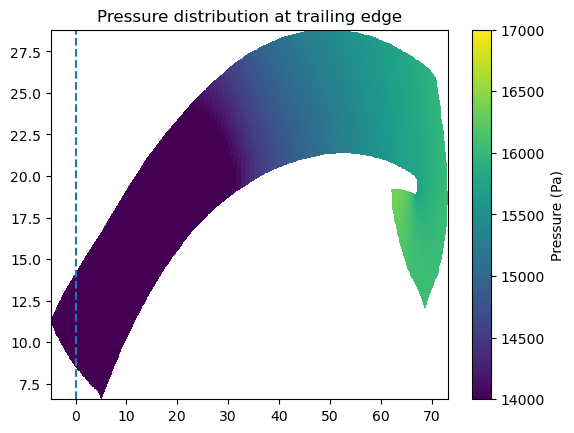

In [76]:
for i in [4,7]:
    pres_i = pp_OGV_RANS._stats1[i]['p']
    vmins.append(pres_i.min())
    vmaxs.append(pres_i.max())
    
vmin = min(vmins)
vmax = max(vmaxs)


for i in [4,7]:
    x_i=pp_OGV_RANS.x[i]
    y_i=pp_OGV_RANS.y[i]
    pres_i = pp_OGV_RANS._stats1[i]['p']
    plt.pcolormesh(x_i,y_i,pres_i,vmin=14000,vmax=17000)
    #contours = plt.contour(x_i,y_i,pres_i)
    
plt.colorbar(label='Pressure (Pa)')
plt.axvline(x=0, linestyle='--')
plt.title('Pressure distribution at trailing edge')

In [77]:
pres_inlet_vec = []
x_inlet = -49

for i in range (1,3):
    for j in range(0,len(pp_OGV_RANS._stats1[i]['p'][0])):
        pres_along_x = pp_OGV_RANS._stats1[i]['p'][:,j]
        x_chosen = min(pres_along_x, key=lambda x: abs(x - x_inlet))
        pres_inlet_pt = pp_OGV_RANS._stats1[i]['p'][x_inlet][j]
        pres_inlet_vec.append(pres_inlet_pt)
        
print("Calculated mean pressure at inlet:", np.mean(pres_inlet_vec), "Pa")
    

Calculated mean pressure at inlet: 14265.1273201173 Pa


### Inlet Pressure

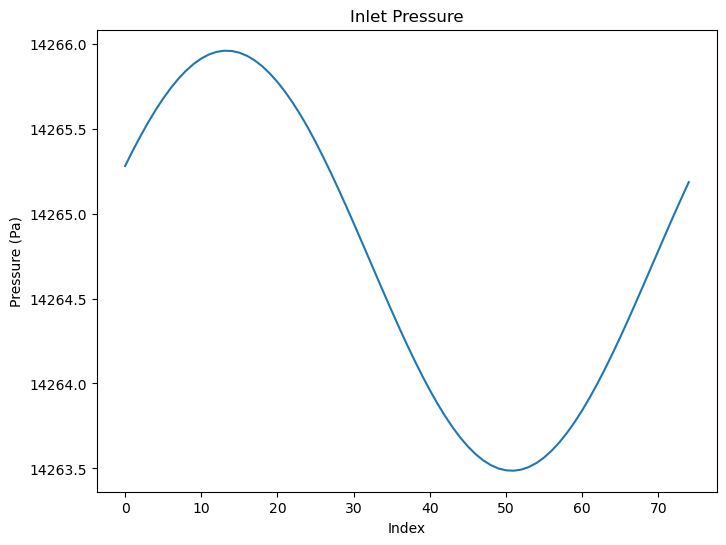

In [78]:
from matplotlib.ticker import ScalarFormatter

pres_inlet_bl1 = pp_OGV_RANS._stats1[1]['p'][0,:]
pres_inlet_bl2 = pp_OGV_RANS._stats1[2]['p'][0,:]

pres_inlet_concatenated = np.concatenate((pres_inlet_bl1,pres_inlet_bl2))

# Create the x-axis range for the concatenated arrays
x_axis = range(len(pres_inlet_concatenated))

# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the concatenated pressure array
ax.plot(x_axis, pres_inlet_concatenated)
ax.set_xlabel('Index')
ax.set_ylabel('Pressure (Pa)')
ax.set_title('Inlet Pressure')

# Suppress scientific notation on the y-axis
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

plt.show()

### Temperature Field 

/tmp/ipykernel_11042/219490609.py:16: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(x_i,y_i,temp_i,vmin=vmin,vmax=vmax)


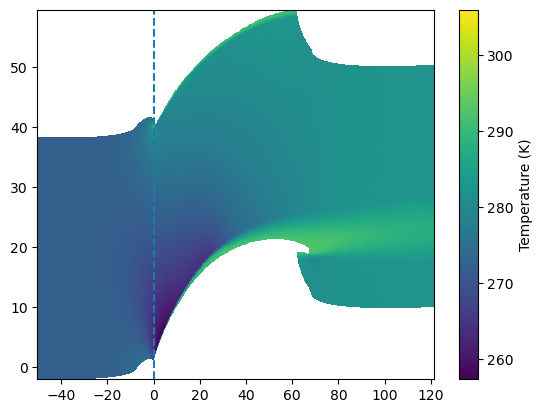

In [79]:
vmins = []
vmaxs = []

for i in range(1,10):
    temp_i = pp_OGV_RANS._stats1[i]['T']
    vmins.append(temp_i.min())
    vmaxs.append(temp_i.max())
    
vmin = min(vmins)
vmax = max(vmaxs)
    
for i in range(1,10):
    x_i=pp_OGV_RANS.x[i]
    y_i=pp_OGV_RANS.y[i]
    temp_i = pp_OGV_RANS._stats1[i]['T']
    plt.pcolormesh(x_i,y_i,temp_i,vmin=vmin,vmax=vmax)
    #contours = plt.contour(x_i,y_i,pres_i)
    
plt.colorbar(label='Temperature (K)')
plt.axvline(x=0, linestyle='--')

### Total Pressure (Assumes isentropic flow)

In [80]:
pres_tot = {i:[] for i in range(1,10)}

for i in range(1,10):
    cp=pp_OGV_RANS._stats2[i]['cp']
    cv=pp_OGV_RANS._stats2[i]['cv']
    gamma = cp/cv
    Mach = pp_OGV_RANS._stats2[i]['M']
    
    pres = pp_OGV_RANS._stats1[i]['p']
    
    pres_tot[i] = pres*(1+ (gamma-1)/2*Mach**2)**(gamma/(gamma-1))
    
    
print(pp_OGV_RANS.x[1])

[[-50.         -50.         -50.         ... -50.         -50.
  -50.        ]
 [-49.42028203 -49.41892688 -49.4182639  ... -49.39975775 -49.39898036
  -49.39828529]
 [-48.84077571 -48.83822189 -48.83699796 ... -48.80359133 -48.80233025
  -48.80134522]
 ...
 [ -8.46226137  -8.53231377  -8.55407893 ...  -6.41926018  -6.40417645
   -6.48307369]
 [ -7.92858993  -8.02338255  -8.05298225 ...  -5.84609888  -5.81698267
   -5.87194965]
 [ -7.43036679  -7.53855535  -7.56409884 ...  -5.33198635  -5.27252954
   -5.25898178]]


/tmp/ipykernel_11042/2822025793.py:14: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(x_i,y_i,pres_tot[i],vmin=vmin,vmax=vmax)


Text(0.5, 1.0, 'Stagnation Pressure Field')

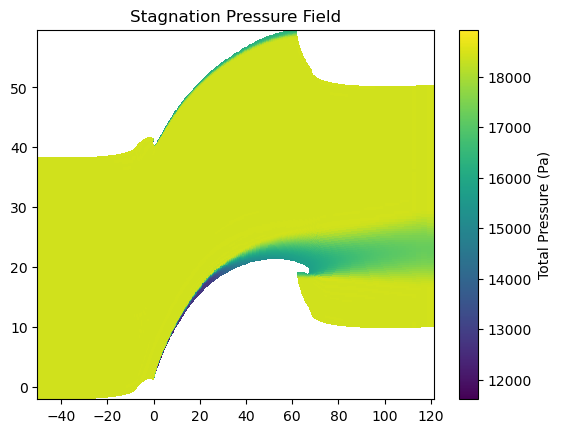

In [81]:
vmins = []
vmaxs = []

for i in range(1,10):
    vmins.append(pres_tot[i].min())
    vmaxs.append(pres_tot[i].max())
    
vmin = min(vmins)
vmax = max(vmaxs)
    
for i in range(1,10):
    x_i=pp_OGV_RANS.x[i]
    y_i=pp_OGV_RANS.y[i]
    plt.pcolormesh(x_i,y_i,pres_tot[i],vmin=vmin,vmax=vmax)
    #plt.pcolormesh(x_i,y_i,pres_tot[i],vmin=18000,vmax=19000)
    #contours = plt.contour(x_i,y_i,pres_i)
    
plt.colorbar(label='Total Pressure (Pa)')
plt.title('Stagnation Pressure Field')

### Total Temperature (Assume isentropic flow)

In [82]:
temp_tot = {i:[] for i in range(1,10)}

for i in range(1,10):
    cp=pp_OGV_RANS._stats2[i]['cp']
    cv=pp_OGV_RANS._stats2[i]['cv']
    gamma = cp/cv
    Mach = pp_OGV_RANS._stats2[i]['M']
    temp = pp_OGV_RANS._stats1[i]['T']
    temp_tot[i] = temp*(1+ (gamma-1)/2*Mach**2)

/tmp/ipykernel_11042/3447441258.py:14: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(x_i,y_i,pres_tot[i],vmin=vmin,vmax=vmax)


Text(0.5, 1.0, 'Stagnation Temperature Field')

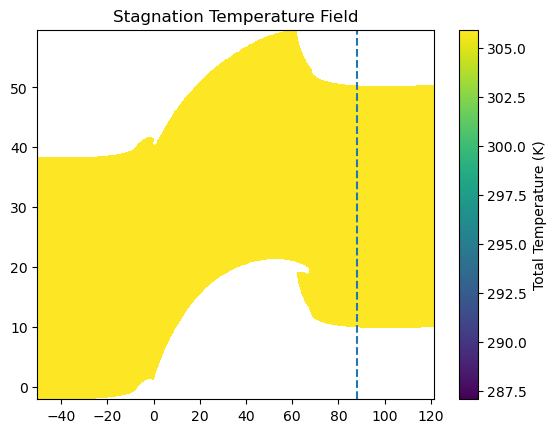

In [83]:
vmins = []
vmaxs = []

for i in range(1,10):
    vmins.append(temp_tot[i].min())
    vmaxs.append(temp_tot[i].max())
    
vmin = min(vmins)
vmax = max(vmaxs)
    
for i in range(1,10):
    x_i=pp_OGV_RANS.x[i]
    y_i=pp_OGV_RANS.y[i]
    plt.pcolormesh(x_i,y_i,pres_tot[i],vmin=vmin,vmax=vmax)
    #plt.pcolormesh(x_i,y_i,pres_tot[i],vmin=297.999,vmax=298)
    #contours = plt.contour(x_i,y_i,pres_i)
    
plt.colorbar(label='Total Temperature (K)')
plt.axvline(x=88, linestyle='--')
plt.title('Stagnation Temperature Field')

### Loss coefficients 

In [84]:
pres_inlet_vec = []
pres_inlet_tot_vec = []
x_inlet = -60

for i in range (1,3):
    for j in range(0,len(pp_OGV_RANS._stats1[i]['p'][0])):
        x_along_y = pp_OGV_RANS.x[i][:,j]
        index_chosen = np.argmin(np.abs(x_along_y - x_inlet))
        
        pres_inlet_pt = pp_OGV_RANS._stats1[i]['p'][index_chosen][j]
        pres_inlet_vec.append(pres_inlet_pt)
        
        pres_inlet_tot_pt = pres_tot[i][index_chosen][j]
        pres_inlet_tot_vec.append(pres_inlet_tot_pt)
        
pres_inlet_mean = np.mean(pres_inlet_vec)
pres_inlet_tot_mean = np.mean(pres_inlet_tot_vec)
        
print("Calculated mean pressure at inlet:", pres_inlet_mean, "Pa")
print("Calculated mean total pressure at inlet:", pres_inlet_tot_mean, "Pa")


Calculated mean pressure at inlet: 14264.728144719938 Pa
Calculated mean total pressure at inlet: 18416.5815550571 Pa


In [85]:
pres_outlet_vec = []
pres_outlet_tot_vec = []
x_outlet = 130

for i in range (8,10):
    for j in range(0,len(pp_OGV_RANS._stats1[i]['p'][0])):
        x_along_y = pp_OGV_RANS.x[i][:,j]
        index_chosen = np.argmin(np.abs(x_along_y - x_outlet))
        
        pres_outlet_pt = pp_OGV_RANS._stats1[i]['p'][index_chosen][j]
        pres_outlet_vec.append(pres_outlet_pt)
        
        pres_outlet_tot_pt = pres_tot[i][index_chosen][j]
        pres_outlet_tot_vec.append(pres_outlet_tot_pt)
        
pres_outlet_mean = np.mean(pres_outlet_vec)
pres_outlet_tot_mean = np.mean(pres_outlet_tot_vec)
        
print("Calculated mean pressure at outlet:", pres_outlet_mean, "Pa")
print("Calculated mean total pressure at outlet:", pres_outlet_tot_mean, "Pa")

Calculated mean pressure at outlet: 16257.98719999996 Pa
Calculated mean total pressure at outlet: 18179.64782049579 Pa


### Mach Number

/tmp/ipykernel_11042/2294197838.py:16: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(x_i,y_i,u_i,vmin=vmin_M,vmax=vmax_M)


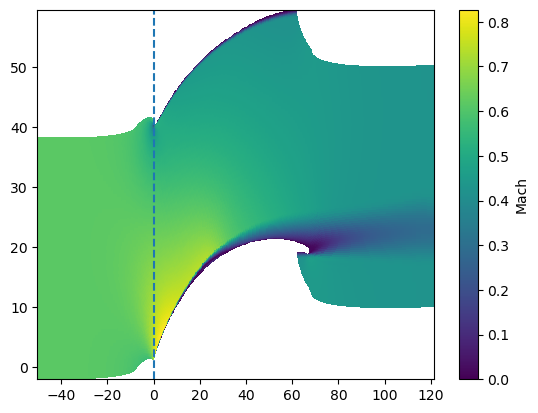

In [86]:
vmins_M = []
vmaxs_M = []

for i in range(1,10):
    M_i = pp_OGV_RANS._stats2[i]['M']
    vmins_M.append(M_i.min())
    vmaxs_M.append(M_i.max())
    
vmin_M = min(vmins_M)
vmax_M = max(vmaxs_M)
    
for i in range(1,10):
    x_i=pp_OGV_RANS.x[i]
    y_i=pp_OGV_RANS.y[i]
    u_i = pp_OGV_RANS._stats2[i]['M']
    plt.pcolormesh(x_i,y_i,u_i,vmin=vmin_M,vmax=vmax_M)
    #contours = plt.contour(x_i,y_i,u_i)
    
plt.colorbar(label='Mach')
plt.axvline(x=0, linestyle='--')

### Velocity Field (Magnitude)

[192.53873842587385, 191.7228296317596, 0.0, 0.0, 147.69839040061143, 0.0, 0.0, 23.27846924089638, 130.56081344937726]
0.0


/tmp/ipykernel_11042/538109246.py:18: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(x_i,y_i,V_i,vmin=vmin_V,vmax=vmax_V)


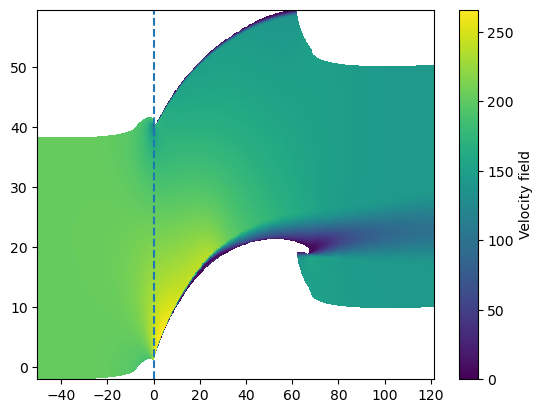

In [87]:
vmins_V = []
vmaxs_V = []

for i in range(1,10):
    V_i = (pp_OGV_RANS._stats1[i]['u']**2 + pp_OGV_RANS._stats1[i]['v']**2)**0.5
    vmins_V.append(V_i.min())
    vmaxs_V.append(V_i.max())

print(vmins_V)
vmin_V = min(vmins_V)
print(vmin_V)
vmax_V = max(vmaxs_V)
    
for i in range(1,10):
    x_i=pp_OGV_RANS.x[i]
    y_i=pp_OGV_RANS.y[i]
    V_i = (pp_OGV_RANS._stats1[i]['u']**2 + pp_OGV_RANS._stats1[i]['v']**2)**0.5
    plt.pcolormesh(x_i,y_i,V_i,vmin=vmin_V,vmax=vmax_V)
    #plt.pcolormesh(x_i,y_i,V_i,vmin=160,vmax=vmax_V)
    #contours = plt.contour(x_i,y_i,u_i)
    
plt.colorbar(label='Velocity field')
plt.axvline(x=0, linestyle='--')

### Velocity Field (y-component)

[135.43784146893123, 131.83565933963445, 0.0, -10.479235405278297, -1.3176024704599225, -3.792520986337712, -7.6317516093624835, -5.286788033136508, -1.5016466812002367]
-10.479235405278297


/tmp/ipykernel_11042/3865202133.py:18: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(x_i,y_i,v_i,vmin=vmin_v,vmax=vmax_v)


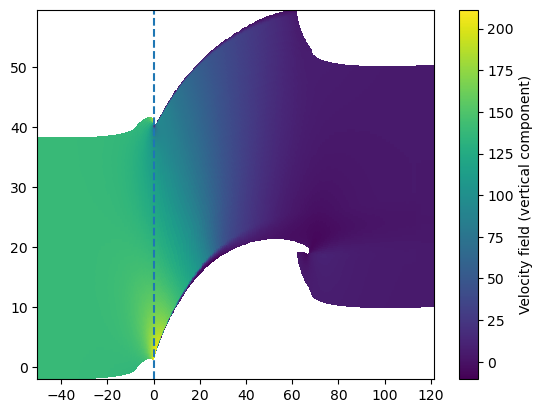

In [88]:
vmins_v = []
vmaxs_v = []

for i in range(1,10):
    v_i = pp_OGV_RANS._stats1[i]['v']
    vmins_v.append(v_i.min())
    vmaxs_v.append(v_i.max())

print(vmins_v)
vmin_v = min(vmins_v)
print(vmin_v)
vmax_v = max(vmaxs_v)
    
for i in range(1,10):
    x_i=pp_OGV_RANS.x[i]
    y_i=pp_OGV_RANS.y[i]
    v_i = pp_OGV_RANS._stats1[i]['v']
    plt.pcolormesh(x_i,y_i,v_i,vmin=vmin_v,vmax=vmax_v)

    
plt.colorbar(label='Velocity field (vertical component)')
plt.axvline(x=0, linestyle='--')

### Inlet velocity

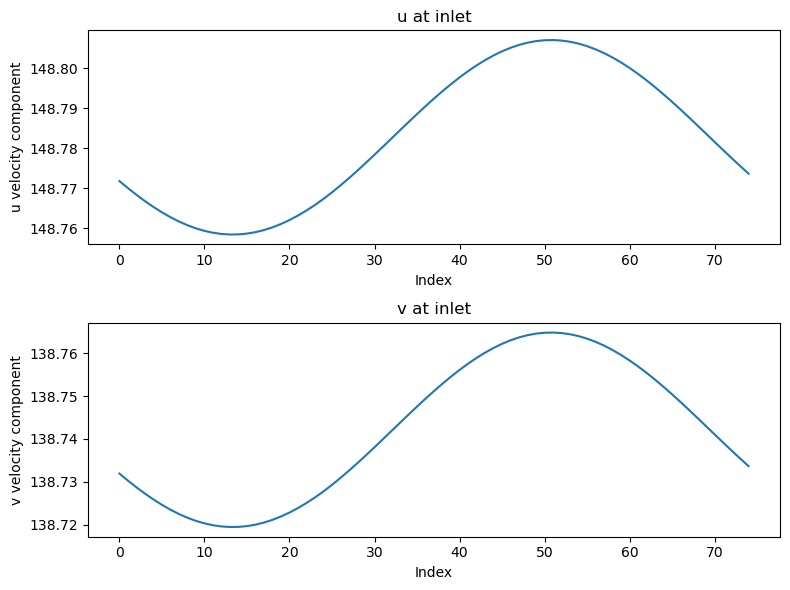

In [89]:
from matplotlib.ticker import ScalarFormatter

u_inlet_bl1 = pp_OGV_RANS._stats1[1]['u'][0,:]
u_inlet_bl2 = pp_OGV_RANS._stats1[2]['u'][0,:]

v_inlet_bl1 = pp_OGV_RANS._stats1[1]['v'][0,:]
v_inlet_bl2 = pp_OGV_RANS._stats1[2]['v'][0,:]

u_inlet_concatenated = np.concatenate((u_inlet_bl1, u_inlet_bl2))
v_inlet_concatenated = np.concatenate((v_inlet_bl1, v_inlet_bl2))

# Create the x-axis range for the concatenated arrays
x_axis = range(len(u_inlet_concatenated))

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

# Plot the concatenated u array in the first subplot
ax1.plot(x_axis, u_inlet_concatenated)
ax1.set_xlabel('Index')
ax1.set_ylabel('u velocity component')
ax1.set_title('u at inlet')

# Plot the concatenated v array in the second subplot
ax2.plot(x_axis, v_inlet_concatenated)
ax2.set_xlabel('Index')
ax2.set_ylabel('v velocity component')
ax2.set_title('v at inlet')

# Suppress scientific notation on the y-axis
for ax in [ax1, ax2]:
    ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))


# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()


### Velocity Vector Field (full field)

(75, 25)
(75, 50)
(25, 50)
(100, 50)
(100, 50)
(100, 50)
(50, 50)
(75, 50)
(75, 50)


/tmp/ipykernel_11042/2116881010.py:58: RuntimeWarning: invalid value encountered in divide
  u_vec_block = u_sub_block / mag_vel_block
/tmp/ipykernel_11042/2116881010.py:59: RuntimeWarning: invalid value encountered in divide
  v_vec_block = v_sub_block / mag_vel_block


Text(0, 0.5, 'y-coordinates')

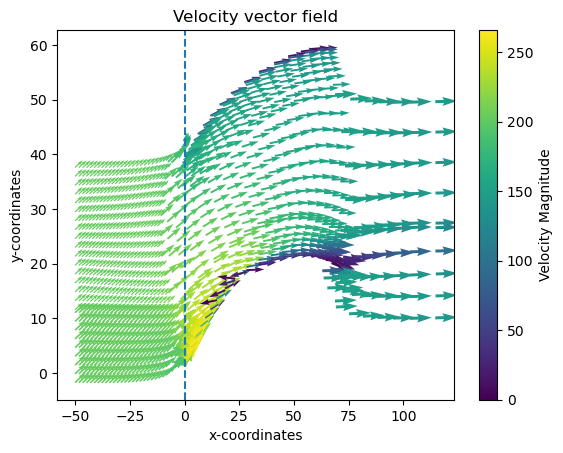

In [90]:
## Store the max and min values at each block
mag_vel_maxs = []
mag_vel_mins = []

pitch_blade = pp_OGV_RANS.y[6][-1][0] - pp_OGV_RANS.y[3][0][0]

for i in range(1,10):
    
    u_i = pp_OGV_RANS._stats1[i]['u']
    v_i = pp_OGV_RANS._stats1[i]['v']
    mag_vel_i = (u_i**2 + v_i**2)**0.5
    
    mag_vel_maxs.append(mag_vel_i.max())
    mag_vel_mins.append(mag_vel_i.min())

## Select the global max and min values among all blocks 
mag_vel_min = min(mag_vel_mins)
mag_vel_max = max(mag_vel_maxs)    

## Moderate the density and size of vectors
stride_i = 3  
stride_j = 3
size_factor = 0.0002  

## Decide the number of j positions (normal to wall) we would like to visualize 
j_selected = 40


for block in range(1,10):
    x_block = pp_OGV_RANS.x[block].copy() ## .copy() to prevent contamination of the original data
    y_block = pp_OGV_RANS.y[block].copy()
    u_block = pp_OGV_RANS._stats1[block]['u']
    v_block = pp_OGV_RANS._stats1[block]['v']
    
    print(x_block.shape)
    
    ## Lower density of vectors at the leading and trailing edge
    if block==3 or block==7:
        stride_i *= 2
        stride_j *= 2
        stride_i = int(stride_i)
        stride_j = int(stride_j)
    
    ## Decide the density of vectors to be plotted
    x_sub_block = x_block[::stride_i,::stride_j]
    y_sub_block = y_block[::stride_i,::stride_j]
    u_sub_block = u_block[::stride_i,::stride_j]
    v_sub_block = v_block[::stride_i,::stride_j]
    
    
    ## Displace block 6 to better visualize the blade
#    if block==6:
#        y_sub_block -= pitch_blade

    mag_vel_block = (u_sub_block**2 + v_sub_block**2)**0.5
    
    ## Normalize the vectors
    u_vec_block = u_sub_block / mag_vel_block 
    v_vec_block = v_sub_block / mag_vel_block
    
    ## Adjust vector size
    u_vec_block *= size_factor
    v_vec_block *= size_factor
    
    ## Store the vector plot for each iteration 
    quiver_plot = plt.quiver(
        x_sub_block, y_sub_block, u_vec_block, v_vec_block, mag_vel_block,
        cmap=plt.cm.viridis,
        clim=(mag_vel_min, mag_vel_max))
    
plt.colorbar(quiver_plot, label='Velocity Magnitude')
    
plt.title('Velocity vector field')
plt.axvline(x=0, linestyle='--')
plt.xlabel('x-coordinates')
plt.ylabel('y-coordinates')


### Velocity vector field (Zoom-in)

(25, 40)
(100, 40)
(100, 40)
(50, 40)


/tmp/ipykernel_11042/1568177240.py:58: RuntimeWarning: invalid value encountered in divide
  u_vec_block = u_sub_block / mag_vel_block
/tmp/ipykernel_11042/1568177240.py:59: RuntimeWarning: invalid value encountered in divide
  v_vec_block = v_sub_block / mag_vel_block


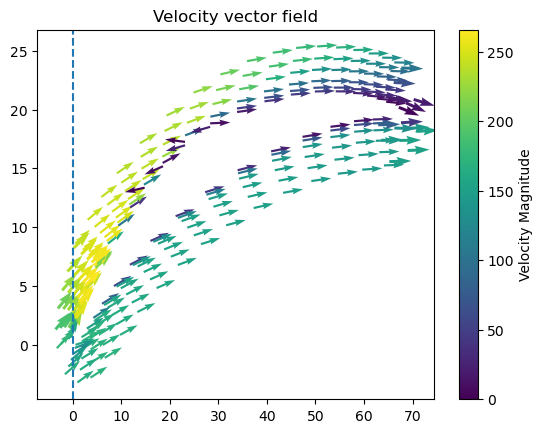

In [91]:
## Store the max and min values at each block
mag_vel_maxs = []
mag_vel_mins = []

pitch_blade = pp_OGV_RANS.y[6][-1][0] - pp_OGV_RANS.y[3][0][0]

for i in [3,4,6,7]:
    
    u_i = pp_OGV_RANS._stats1[i]['u']
    v_i = pp_OGV_RANS._stats1[i]['v']
    mag_vel_i = (u_i**2 + v_i**2)**0.5
    
    mag_vel_maxs.append(mag_vel_i.max())
    mag_vel_mins.append(mag_vel_i.min())

## Select the global max and min values among all blocks 
mag_vel_min = min(mag_vel_mins)
mag_vel_max = max(mag_vel_maxs)    

## Moderate the density and size of vectors
stride_i = 3  
stride_j = 3
size_factor = 0.0002  

## Decide the number of j positions (normal to wall) we would like to visualize 
j_selected = 40


for block in [3,4,6,7]:
    x_block = pp_OGV_RANS.x[block][:,range(j_selected)].copy() ## .copy() to prevent contamination of the original data
    y_block = pp_OGV_RANS.y[block][:,range(j_selected)].copy()
    u_block = pp_OGV_RANS._stats1[block]['u'][:,range(j_selected)]
    v_block = pp_OGV_RANS._stats1[block]['v'][:,range(j_selected)]
    
    print(x_block.shape)
    
    ## Lower density of vectors at the leading and trailing edge
    if block==3 or block==7:
        stride_i *= 2
        stride_j *= 2
        stride_i = int(stride_i)
        stride_j = int(stride_j)
    
    ## Decide the density of vectors to be plotted
    x_sub_block = x_block[::stride_i,::stride_j]
    y_sub_block = y_block[::stride_i,::stride_j]
    u_sub_block = u_block[::stride_i,::stride_j]
    v_sub_block = v_block[::stride_i,::stride_j]
    
    
    ## Displace block 6 to better visualize the blade
    if block==6:
        y_sub_block -= pitch_blade

    mag_vel_block = (u_sub_block**2 + v_sub_block**2)**0.5
    
    ## Normalize the vectors
    u_vec_block = u_sub_block / mag_vel_block 
    v_vec_block = v_sub_block / mag_vel_block
    
    ## Adjust vector size
    u_vec_block *= size_factor
    v_vec_block *= size_factor
    
    ## Store the vector plot for each iteration 
    quiver_plot = plt.quiver(
        x_sub_block, y_sub_block, u_vec_block, v_vec_block, mag_vel_block,
        cmap=plt.cm.viridis,
        clim=(mag_vel_min, mag_vel_max))
    
plt.colorbar(quiver_plot, label='Velocity Magnitude')
    
plt.title('Velocity vector field')
plt.axvline(x=0, linestyle='--')


### Velocity vector field (zoom zoom in)

/tmp/ipykernel_11042/4190332672.py:20: RuntimeWarning: invalid value encountered in divide
  u_vec_i = u_sub_i / mag_vel_i
/tmp/ipykernel_11042/4190332672.py:21: RuntimeWarning: invalid value encountered in divide
  v_vec_i = v_sub_i / mag_vel_i


Text(0, 0.5, 'y-coordinates')

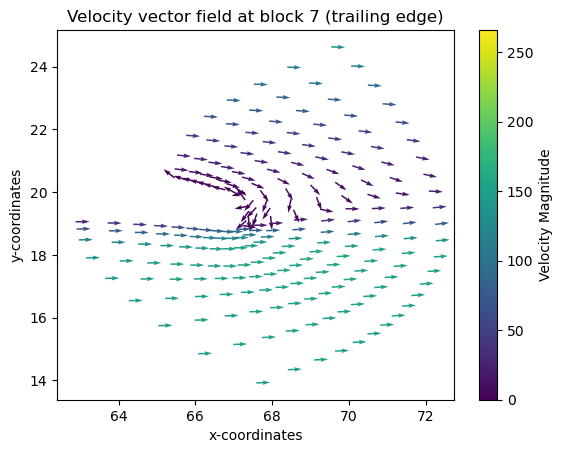

In [92]:
stride_i = 2  ## Density of the vectors
stride_j = 5
size_factor = 0.1     ## Size of the vectors

for i in [7]:
    x_i = pp_OGV_RANS.x[i]
    y_i = pp_OGV_RANS.y[i]
    u_i = pp_OGV_RANS._stats1[i]['u']
    v_i = pp_OGV_RANS._stats1[i]['v']
    
    x_sub_i = x_i[::stride_i,::stride_j]
    y_sub_i = y_i[::stride_i,::stride_j]
    u_sub_i = u_i[::stride_i,::stride_j]
    v_sub_i = v_i[::stride_i,::stride_j]

    mag_vel_i = (u_sub_i**2 + v_sub_i**2)**0.5
    
    #print(mag_vel_i)
    
    u_vec_i = u_sub_i / mag_vel_i 
    v_vec_i = v_sub_i / mag_vel_i
         
    u_vec_i *= size_factor
    v_vec_i *= size_factor

    
    # Store the quiver plot for the colorbar
    quiver_plot = plt.quiver(
        x_sub_i, y_sub_i, u_vec_i, v_vec_i, mag_vel_i,
        cmap=plt.cm.viridis,
        clim=(mag_vel_min, mag_vel_max))
    
plt.colorbar(quiver_plot, label='Velocity Magnitude')
    
plt.title('Velocity vector field at block 7 (trailing edge)')
plt.xlabel('x-coordinates')
plt.ylabel('y-coordinates')


/tmp/ipykernel_11042/3110246816.py:20: RuntimeWarning: invalid value encountered in divide
  u_vec_i = u_sub_i / mag_vel_i
/tmp/ipykernel_11042/3110246816.py:21: RuntimeWarning: invalid value encountered in divide
  v_vec_i = v_sub_i / mag_vel_i


Text(0.5, 1.0, 'Velocity vector field at block 4 (extrado)')

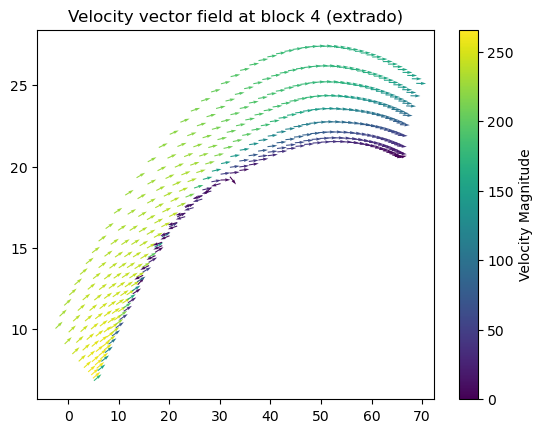

In [93]:
stride_i = 2  ## Density of the vectors
stride_j = 5
size_factor = 0.1     ## Size of the vectors

for i in [4]:
    x_i = pp_OGV_RANS.x[i]
    y_i = pp_OGV_RANS.y[i]
    u_i = pp_OGV_RANS._stats1[i]['u']
    v_i = pp_OGV_RANS._stats1[i]['v']
    
    x_sub_i = x_i[::stride_i,::stride_j]
    y_sub_i = y_i[::stride_i,::stride_j]
    u_sub_i = u_i[::stride_i,::stride_j]
    v_sub_i = v_i[::stride_i,::stride_j]

    mag_vel_i = (u_sub_i**2 + v_sub_i**2)**0.5
    
    #print(mag_vel_i)
    
    u_vec_i = u_sub_i / mag_vel_i 
    v_vec_i = v_sub_i / mag_vel_i
         
    u_vec_i *= size_factor
    v_vec_i *= size_factor

    
    # Store the quiver plot for the colorbar
    quiver_plot = plt.quiver(
        x_sub_i, y_sub_i, u_vec_i, v_vec_i, mag_vel_i,
        cmap=plt.cm.viridis,
        clim=(mag_vel_min, mag_vel_max))
    
plt.colorbar(quiver_plot, label='Velocity Magnitude')
    
plt.title('Velocity vector field at block 4 (extrado)')


### Vorticity 

shape at block 1 is (75, 25)
shape at block 2 is (75, 50)
shape at block 3 is (25, 50)
shape at block 4 is (100, 50)
shape at block 5 is (100, 50)
shape at block 6 is (100, 50)
shape at block 7 is (50, 50)
shape at block 8 is (75, 50)
shape at block 9 is (75, 50)


/tmp/ipykernel_11042/2994351754.py:47: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(x_i,y_i,mag_ohm_i,vmin=vmin_ohm,vmax=1000)


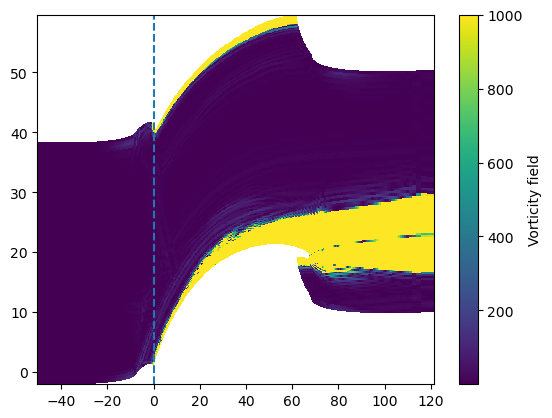

In [94]:
vmins_ohm = []
vmaxs_ohm = []

for i in range(1,10):
    duy_i = (pp_OGV_RANS._stats2[i]['duy^2'])**0.5
    dvx_i = (pp_OGV_RANS._stats2[i]['dvx^2'])**0.5
    duz_i = (pp_OGV_RANS._stats2[i]['duz^2'])**0.5
    dwx_i = (pp_OGV_RANS._stats2[i]['dwx^2'])**0.5
    dvz_i = (pp_OGV_RANS._stats2[i]['dvz^2'])**0.5
    dwy_i = (pp_OGV_RANS._stats2[i]['dwy^2'])**0.5
    
    ohm12_i = 0.5*(duy_i-dvx_i)
    ohm13_i = 0.5*(duz_i-dwx_i)
    ohm23_i = 0.5*(dvz_i-dwy_i)
    
    #mag_ohm_i = (4.0*(ohm12_i**2))**0.5
    mag_ohm_i = (4.0*(ohm12_i**2+ohm13_i**2+ohm23_i**2))**0.5
    
    print(f"shape at block {i} is {mag_ohm_i.shape}")
    
    vmins_ohm.append(mag_ohm_i.min())
    vmaxs_ohm.append(mag_ohm_i.max())
    
vmin_ohm = min(vmins_ohm)
vmax_ohm = max(vmaxs_ohm)
    
for i in range(1,10):
    x_i=pp_OGV_RANS.x[i]
    y_i=pp_OGV_RANS.y[i]
    
    duy_i = (pp_OGV_RANS._stats2[i]['duy^2'])**0.5
    dvx_i = (pp_OGV_RANS._stats2[i]['dvx^2'])**0.5
    duz_i = (pp_OGV_RANS._stats2[i]['duz^2'])**0.5
    dwx_i = (pp_OGV_RANS._stats2[i]['dwx^2'])**0.5
    dvz_i = (pp_OGV_RANS._stats2[i]['dvz^2'])**0.5
    dwy_i = (pp_OGV_RANS._stats2[i]['dwy^2'])**0.5
    
    ohm12_i = 0.5*(duy_i-dvx_i)
    ohm13_i = 0.5*(duz_i-dwx_i)
    ohm23_i = 0.5*(dvz_i-dwy_i)
    
    #mag_ohm_i = (4.0*(ohm12_i**2))**0.5
    mag_ohm_i = (4.0*(ohm12_i**2+ohm13_i**2+ohm23_i**2))**0.5
    
    #plt.pcolormesh(x_i,y_i,mag_ohm_i,vmin=vmin_ohm,vmax=vmax_ohm)
    #plt.pcolormesh(x_i,y_i,mag_ohm_i,vmin=0,vmax=2000)
    plt.pcolormesh(x_i,y_i,mag_ohm_i,vmin=vmin_ohm,vmax=1000)
    
plt.colorbar(label='Vorticity field')
plt.axvline(x=0, linestyle='--')

### Maximum or minimum values

In [95]:
## Find the maximum x on the airfoil 
x_trailing_edge = np.max(pp_OGV_RANS.x[7][:,0])

print(f"x-coordinate of trailing edge is: {x_trailing_edge}")

x-coordinate of trailing edge is: 67.2518755669357


In [96]:
## Find the minimum x on the airfoil 
x_leading_edge = np.min(pp_OGV_RANS.x[6][:,0])

print(f"x-coordinate of leading edge is: {x_leading_edge}")

x-coordinate of leading edge is: -0.108296003270904


In [97]:
## Find the maximum x in the flow field 

overall_max_x = None

# Iterate through the dictionary to find the maximum value in each matrix
for key, matrix in pp_OGV_RANS.x.items():
    matrix_max = np.max(matrix)
    print(f"Maximum value in {key}: {matrix_max}")

    # Update the overall maximum value if the current matrix_max is greater
    if overall_max_x is None or matrix_max > overall_max_x:
        overall_max_x = matrix_max

# Print the overall maximum value
print(f"Overall maximum value among the 9 matrices: {overall_max_x}")

Maximum value in 1: -5.25898177685746
Maximum value in 2: -5.43889512050818
Maximum value in 3: 4.86586877702553
Maximum value in 4: 70.495697491097
Maximum value in 5: 73.068359195933
Maximum value in 6: 68.1048326244715
Maximum value in 7: 73.0456161160191
Maximum value in 8: 120.0
Maximum value in 9: 120.0
Overall maximum value among the 9 matrices: 120.0


In [98]:
## Find the minimum x in the flow field 

overall_min_x = None

# Iterate through the dictionary to find the maximum value in each matrix
for key, matrix in pp_OGV_RANS.x.items():
    matrix_min = np.min(matrix)
    print(f"Maximum value in {key}: {matrix_min}")

    # Update the overall maximum value if the current matrix_max is greater
    if overall_min_x is None or matrix_min < overall_min_x:
        overall_min_x = matrix_min

# Print the overall minimum value
print(f"Overall minimum value among the 9 matrices: {overall_min_x}")

Maximum value in 1: -50.0
Maximum value in 2: -50.0
Maximum value in 3: -7.08336412602324
Maximum value in 4: -4.37080976346271
Maximum value in 5: -11.1268363149958
Maximum value in 6: -6.79494884342434
Maximum value in 7: 62.3648315604349
Maximum value in 8: 69.1303984055961
Maximum value in 9: 68.7467857834602
Overall minimum value among the 9 matrices: -50.0


In [99]:
## Find the maximum y in the flow field 

overall_max_y = None

# Iterate through the dictionary to find the maximum value in each matrix
for key, matrix in pp_OGV_RANS.y.items():
    matrix_max = np.max(matrix)
    print(f"Maximum value in {key}: {matrix_max}")

    # Update the overall maximum value if the current matrix_max is greater
    if overall_max_y is None or matrix_max > overall_max_y:
        overall_max_y = matrix_max

# Print the overall maximum value
print(f"Overall maximum value among the 9 matrices: {overall_max_y}")

Maximum value in 1: 11.0452413372082
Maximum value in 2: 39.6553881665333
Maximum value in 3: 10.7638146185117
Maximum value in 4: 28.634586550367
Maximum value in 5: 51.6288519800359
Maximum value in 6: 59.6194276833702
Maximum value in 7: 25.4375512038503
Maximum value in 8: 27.0048455124701
Maximum value in 9: 51.7652081759605
Overall maximum value among the 9 matrices: 59.6194276833702


In [100]:
## Find the minimum y in the flow field 

overall_min_y = None

# Iterate through the dictionary to find the maximum value in each matrix
for key, matrix in pp_OGV_RANS.y.items():
    matrix_min = np.min(matrix)
    print(f"Minimum value in {key}: {matrix_min}")

    # Update the overall maximum value if the current matrix_max is greater
    if overall_min_y is None or matrix_min < overall_min_y:
        overall_min_y = matrix_min

# Print the overall minimum value
print(f"Overall minimum value among the 9 matrices: {overall_min_y}")

Minimum value in 1: -1.79499960285213
Minimum value in 2: 11.3687664735162
Minimum value in 3: 0.268789873359187
Minimum value in 4: 6.73387534017442
Minimum value in 5: 11.7063419973938
Minimum value in 6: 33.6006250624306
Minimum value in 7: 12.4476562902525
Minimum value in 8: 10.0045628740217
Minimum value in 9: 26.0944897069756
Overall minimum value among the 9 matrices: -1.79499960285213


In [101]:
## Find the maximum total pressure in the flow field 

overall_max_pres_tot = None

# Iterate through the dictionary to find the maximum value in each matrix
for key, matrix in pres_tot.items():
    matrix_max = np.max(matrix)
    print(f"Maximum value in {key}: {matrix_max}")

    # Update the overall maximum value if the current matrix_max is greater
    if overall_max_pres_tot is None or matrix_max > overall_max_pres_tot:
        overall_max_pres_tot = matrix_max

# Print the overall maximum value
print(f"Overall maximum value among the 9 matrices: {overall_max_pres_tot}")

Maximum value in 1: 18418.94650066727
Maximum value in 2: 18420.958281792686
Maximum value in 3: 18418.694675256374
Maximum value in 4: 18574.245222694906
Maximum value in 5: 18420.641408755793
Maximum value in 6: 18931.631001099402
Maximum value in 7: 18469.319594002856
Maximum value in 8: 18476.017909730457
Maximum value in 9: 18426.740190532615
Overall maximum value among the 9 matrices: 18931.631001099402


In [102]:
## Find the maximum total pressure in the inlet blocks 

inlet_max_pres_tot = None

# Iterate through the dictionary to find the maximum value in each matrix
for key, matrix in pres_tot.items():
    if key in [1,2]: #Only include the inlet blocks 
        matrix_max = np.max(matrix)
        print(f"Maximum value in {key}: {matrix_max}")

        # Update the overall maximum value if the current matrix_max is greater
        if inlet_max_pres_tot is None or matrix_max > inlet_max_pres_tot:
            inlet_max_pres_tot = matrix_max

# Print the overall maximum value
print(f"Overall maximum value among the two inlet blocks: {inlet_max_pres_tot}")

Maximum value in 1: 18418.94650066727
Maximum value in 2: 18420.958281792686
Overall maximum value among the two inlet blocks: 18420.958281792686


### y+

In [103]:
#yplus,uplus = pp_OGV_RANS.wall_units()

In [104]:
## Calculate utau

filepath_wall_vector = '/home/johnson/Desktop/MUSICAA/OGV_RANS/OGV_RANS_20241107_nu_6e-3/norm_surf.dat'

df = pd.read_csv(filepath_wall_vector, sep='\s+', header=None)

# Step 2: Extract x and y components of the vectors

#Define normal vectors
nx = df[2]
nx = np.array(nx)
ny = df[3]
ny = np.array(ny)
normal = np.array([nx, ny])

#Define tangent vectors
tx = -ny 
ty = nx 
tangent = np.array([tx, ty])

#ny = np.ones(pp_OGV_RANS._nx_tot)

#print(nx)

In [105]:
#Extract the wall values 
tau_w, utau, Cf, Re_tau, y_plus_x, x_plus_x, tu_mean, tu_x, tu_y, tu_z, y_delta, y_1,y_0, y_plus_x_real= pp_OGV_RANS.calc_bl(normal_w=normal, tangent_w=tangent, is_turb=True)

/home/johnson/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/johnson/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [106]:
x_list = []

for i in [3,4,6,7]:
    
    new_x_value = pp_OGV_RANS.x[i][:,0]
    
    x_list.append(new_x_value)

x_wall = np.concatenate(x_list)

print(len(x_wall))

275


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


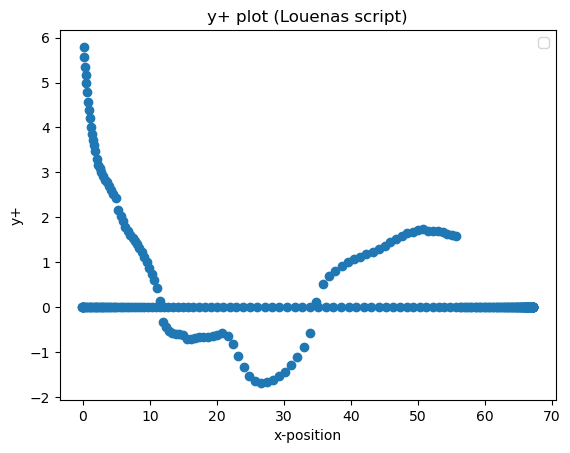

In [107]:
plt.scatter(x_wall,y_plus_x)
plt.title('y+ plot (Louenas script)')
plt.ylabel('y+')
plt.xlabel('x-position')
plt.legend()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


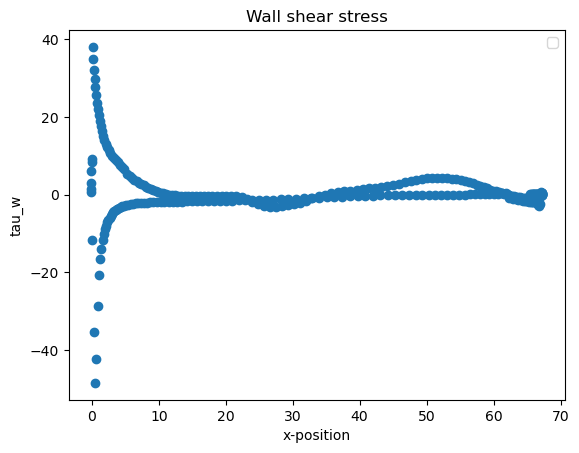

In [108]:
plt.scatter(x_wall,tau_w)
plt.title('Wall shear stress')
plt.ylabel('tau_w')
plt.xlabel('x-position')
plt.legend()
plt.show()

In [109]:
x0_list = []
x1_list = []
y0_list = []
y1_list = []

Roref = 0.219261536536
Muref = 1.81068915267e-05

for i in [3,4,6,7]:
    
    new_x0_value = pp_OGV_RANS.x[i][:,0]
    x0_list.append(new_x0_value)
    
    new_x1_value = pp_OGV_RANS.x[i][:,1]
    x1_list.append(new_x1_value)
    
    new_y0_value = pp_OGV_RANS.y[i][:,0]
    y0_list.append(new_y0_value)
    
    new_y1_value = pp_OGV_RANS.y[i][:,1]
    y1_list.append(new_y1_value)

    
#yplus = np.concatenate(yplus_list)
x0_concat = np.concatenate(x0_list)
x1_concat = np.concatenate(x1_list)
y0_concat = np.concatenate(y0_list)
y1_concat = np.concatenate(y1_list)


In [110]:
yplus = np.zeros(len(x0_concat)).tolist()
yplus_deltay_only = np.zeros(len(x0_concat)).tolist()

for i in range(len(yplus)):
    yplus[i] = abs(utau[i]) * np.sqrt((y1_concat[i] - y0_concat[i])**2 + (x1_concat[i] - x0_concat[i])**2)/1000 * Roref / Muref

    
for i in range(len(yplus_deltay_only)):
    yplus_deltay_only[i] = abs(utau[i]) * abs((y1_concat[i] - y0_concat[i]))/1000 * Roref / Muref
    
print('The mean y+ is', np.mean(np.array(yplus)))
  

The mean y+ is 1.3612793216499297


Text(0.5, 1.0, 'yplus plot')

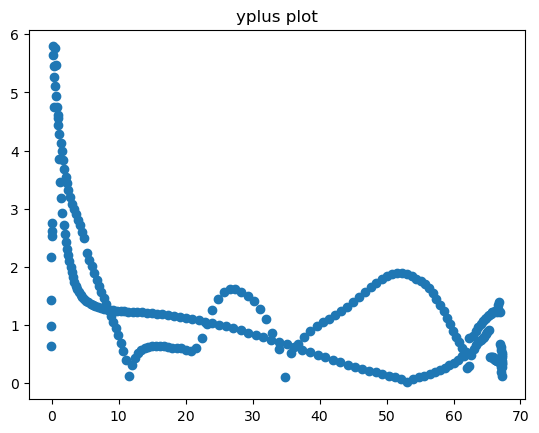

In [111]:
plt.scatter(x0_concat,yplus)
plt.title('yplus plot')

Text(0.5, 1.0, 'yplus delta y only')

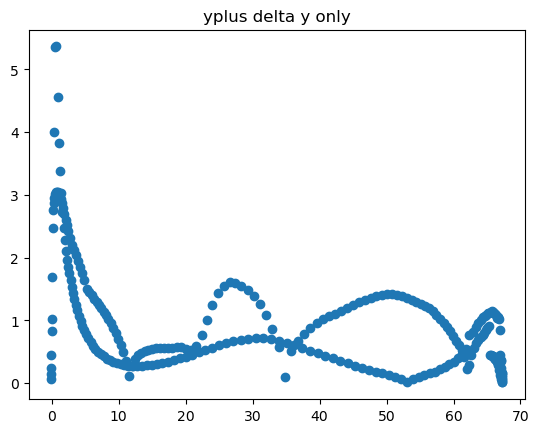

In [112]:
plt.scatter(x0_concat,yplus_deltay_only)
plt.title('yplus delta y only')

Text(0.5, 1.0, 'tau wall plot')

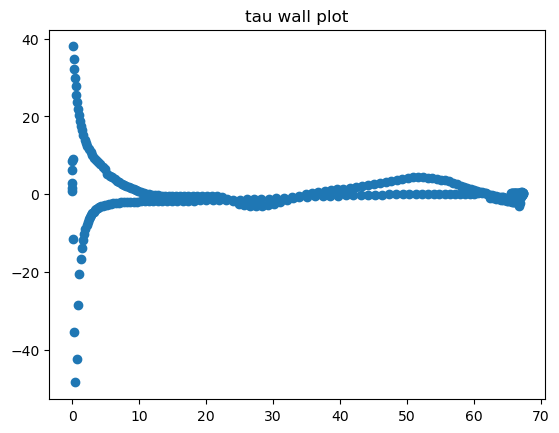

In [113]:
plt.scatter(x0_concat,tau_w)
plt.title('tau wall plot')

Text(0.5, 1.0, 'utau plot')

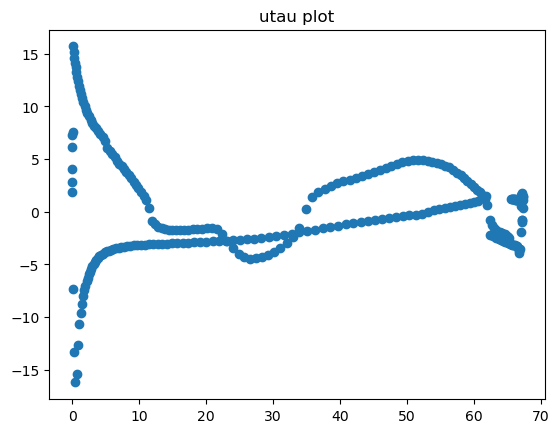

In [114]:
plt.scatter(x0_concat,utau)
plt.title('utau plot')

### Freestream values and corresponding positions

In [115]:
from scipy.interpolate import LinearNDInterpolator


## Initialize vectors that store full field data
ohm_global=[]
vel_global = []
x_global=[]
y_global=[]
rho_global=[]

## Compute the field values at each block, combine them and store them in one single list (xx_global)
for i in range(1,10):
    ## Compute the vorticity at every point in the flow field
    duy_i = (pp_OGV_RANS._stats2[i]['duy^2'])**0.5
    dvx_i = (pp_OGV_RANS._stats2[i]['dvx^2'])**0.5
    duz_i = (pp_OGV_RANS._stats2[i]['duz^2'])**0.5
    dwx_i = (pp_OGV_RANS._stats2[i]['dwx^2'])**0.5
    dvz_i = (pp_OGV_RANS._stats2[i]['dvz^2'])**0.5
    dwy_i = (pp_OGV_RANS._stats2[i]['dwy^2'])**0.5
    
    ohm12_i = 0.5*(duy_i-dvx_i)
    ohm13_i = 0.5*(duz_i-dwx_i)
    ohm23_i = 0.5*(dvz_i-dwy_i)
    
    ## 2D simplified case
    #mag_ohm_i = (4.0*(ohm12_i**2))**0.5
    
    ohm_i = (4.0*(ohm12_i**2+ohm13_i**2+ohm23_i**2))**0.5
    ohm = ohm_i.flatten()
    ohm_global.extend(ohm)

    rho = pp_OGV_RANS._stats1[i]["rho"].flatten()
    rho_global.extend(rho)
    
    u = pp_OGV_RANS._stats1[i]["u"].flatten()
    v = pp_OGV_RANS._stats1[i]["v"].flatten()
    vel = (u**2+v**2)**0.5
    vel_global.extend(vel)
    
    x = pp_OGV_RANS.x[i].flatten()
    x_global.extend(x)
    
    y = pp_OGV_RANS.y[i].flatten()
    y_global.extend(y)

len(x_global)

31875

In [116]:
## Define interpolation functions to allow access to field values at arbitrary positions in the flow field

vel_interpolator = LinearNDInterpolator(list(zip(x_global, y_global)), vel_global)
ohm_interpolator = LinearNDInterpolator(list(zip(x_global,y_global)), ohm_global)
rho_interpolator = LinearNDInterpolator(list(zip(x_global,y_global)),rho_global)

In [117]:
## Initialise a dictionary to store the number of x positions at each wall block 
num_x_wall={}

## Import and define normal vectors
filepath_wall_vector = '/home/johnson/Desktop/MUSICAA/OGV_RANS/OGV_RANS_20241107_nu_6e-3/norm_surf.dat'

df = pd.read_csv(filepath_wall_vector, sep='\s+', header=None)

#Define normal vectors (normalised)
nx = df[2]
nx = np.array(nx)
ny = df[3]
ny = np.array(ny)
#normal = np.array([nx, ny])

##Define the key names (block number) and the corresponding number of normal vector elements
normalDictInfo = {"3":pp_OGV_RANS.nx[3],"4":pp_OGV_RANS.nx[4],"6":pp_OGV_RANS.nx[6],"7":pp_OGV_RANS.nx[7]}
vec_nx = {}
vec_ny = {}

## Assign the keys and values to the dictionary 
index=0
for key,nn in normalDictInfo.items():
    vec_nx[key] = nx[index:index+nn]
    vec_ny[key] = ny[index:index+nn]
    index += nn

## Store the key names as numerical values instead of text
vec_nx = {int(k):v for k,v in vec_nx.items()}
vec_ny = {int(k):v for k,v in vec_ny.items()}


## Assign the number of x positions in each wall block to the dictionary initialized earlier
for i in [3,4,6,7]:
    ## Attention: nx in this for loop refers to the number of points, not normal vectors defined earlier
    num_x_wall[i] = pp_OGV_RANS.nx[i] 
    
num_x_wall[3]
print(vec_nx.keys())
print(pp_OGV_RANS.x.keys())

dict_keys([3, 4, 6, 7])
dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9])


In [118]:
print(deg_dict[7])

[ 78.24613373  78.23127924  77.23680075  77.24083485  76.86574389
  76.58433174  76.74936268  69.72030864  33.19984704  14.34223713
   2.27167858  -9.95613048 -24.27078811 -40.45191147 -60.10769244
 -88.07781235  80.50797165  81.50212994  82.25701393  83.32669793
  84.39769684  85.18947021  86.41810826  87.61759624  88.8013967 ]


In [119]:
## Spatial step size in the direction normal to the wall at each i position  
delta = 0.01

## Vorticity threshold below which the flow is regarded as freestream
ohm_threshold = 1000

## The following dictionaries store for each wall block, the field value of the position that marks
## the start of freestream for each normal vector stemmed from wall position i 
x_infty_n = {}  # x-position
y_infty_n = {}  # y-position
ohm_infty_n = {} # vorticity 
vel_infty_n = {}  # velocity 
rho_infty_n = {}  # density
j_infty_n = {}    # index j in self.x[bloc] and self.y[bloc]


## Positions where interpolated values are evaluated along the normal vectors at position i for each block
x_interp_normal = {}
y_interp_normal = {}

for block in [3,4,6,7]:
    ## Initialization
    x_infty_n[block] = []
    y_infty_n[block] = []
    ohm_infty_n[block] = []
    vel_infty_n[block] = []
    rho_infty_n[block] = []
    j_infty_n[block] = []
    
    x_interp_normal[block] = {}
    y_interp_normal[block] = {}
    
    for i in range(num_x_wall[block]): 
        
        ## Initalize a list to store positions at all j indices at each i
        x_interp_normal[block][i] = []
        y_interp_normal[block][i] = []
        
        j=0
        while True:
            
            ## Explicitly abandon interpolation functions for j=0 to avoid issues
            if j==0:
                x_interp_n = pp_OGV_RANS.x[block][i,0]
                y_interp_n = pp_OGV_RANS.y[block][i,0]
                vel_interp_n = (pp_OGV_RANS._stats1[block]['u'][i,0]**2+pp_OGV_RANS._stats1[block]['v'][i,0]**2)**0.5
                rho_interp_n = pp_OGV_RANS._stats1[block]['rho'][i,0]
                
                duy = (pp_OGV_RANS._stats2[block]['duy^2'][i,0])**0.5
                dvx = (pp_OGV_RANS._stats2[block]['dvx^2'][i,0])**0.5
                duz = (pp_OGV_RANS._stats2[block]['duz^2'][i,0])**0.5
                dwx = (pp_OGV_RANS._stats2[block]['dwx^2'][i,0])**0.5
                dvz = (pp_OGV_RANS._stats2[block]['dvz^2'][i,0])**0.5
                dwy = (pp_OGV_RANS._stats2[block]['dwy^2'][i,0])**0.5

                ohm12 = 0.5*(duy-dvx)
                ohm13 = 0.5*(duz-dwx)
                ohm23 = 0.5*(dvz-dwy)

                ohm_interp_n = (4.0*(ohm12**2+ohm13**2+ohm23**2))**0.5
                
                j_interp_n = j
                
                #print(f"Here we are at j=0, block: {block}, i: {i},rho: {rho_interp_n}")
                
            else:
                
                
                ## Marching the normal vector with given step size (delta) from each wall position
                x_interp_n = pp_OGV_RANS.x[block][i,0] + vec_nx[block][i]*delta*j
                y_interp_n = pp_OGV_RANS.y[block][i,0] + vec_ny[block][i]*delta*j

                ## Compute the distance from wall at each evaluated point
                dist = ((x_interp_n - pp_OGV_RANS.x[block][i,0])**2 + (y_interp_n - pp_OGV_RANS.y[block][i,0])**2)**0.5

                ## Compute the the vorticity, velocity and density using the interpolation function
                ohm_interp_n = ohm_interpolator(x_interp_n, y_interp_n) 
                vel_interp_n = vel_interpolator(x_interp_n,y_interp_n)
                rho_interp_n = rho_interpolator(x_interp_n,y_interp_n)

                ## Store the corresponding j index
                j_interp_n = j

                #if block == 6:
                    #print(f"position is {x_interp_n}, {y_interp_n},i={i}, j = {j_interp_n}")
                    #print(f"vorticity is {ohm_interp_n}")

                #print(f"block: {block}, i: {i},j: {j},x: {x_interp_n:.3f}, y: {y_interp_n:.3f}, rho: {rho_interp_n:.3f}, ohm: {ohm_interp_n:.3f}")

                x_interp_normal[block][i].append(x_interp_n)
                y_interp_normal[block][i].append(y_interp_n)

                ## Stop the while loop when vorticity reaches freestream threshold or a nan is produced 
                if ohm_interp_n < ohm_threshold:
                    break
                elif np.isnan(ohm_interp_n) or np.isnan(vel_interp_n) or np.isnan(rho_interp_n):
                    print(f"NaN detected at block {block}, i={i}, j={j},x={x_interp_n:.2f},y={y_interp_n:.2f} ,ohm={ohm_interp_n}, vel={vel_interp_n}, rho={rho_interp_n}, dist={dist:.3f}")
                    break
            j+=1

        ## Store the last values right before the while loop breaks
        x_infty_n[block].append(x_interp_n)
        y_infty_n[block].append(y_interp_n)
        ohm_infty_n[block].append(ohm_interp_n)
        vel_infty_n[block].append(vel_interp_n)
        rho_infty_n[block].append(rho_interp_n)
        j_infty_n[block].append(j_interp_n)

        
print(f"Done!")       
#print(len(x_infty_n[7]))
#print(num_x_wall[7])
#print(pp_OGV_RANS.nx[7])

#print(x_interp_normal[7][0][8])

NaN detected at block 6, i=99, j=1155,x=-10.37,y=46.31 ,ohm=nan, vel=nan, rho=nan, dist=11.550
NaN detected at block 7, i=20, j=5279,x=120.00,y=21.54 ,ohm=nan, vel=nan, rho=nan, dist=52.790
Done!


In [120]:
print(j_infty_n[3])

[33, 66, 56, 57, 40, 40, 40, 63, 45, 45, 45, 68, 50, 50, 50, 30, 55, 33, 34, 35, 25, 31, 61, 37, 69]


In [121]:
#%whos

### Wall Normal Vector Plots 

Text(0.5, 1.0, 'Normal vectors on block 7 (trailing edge)')

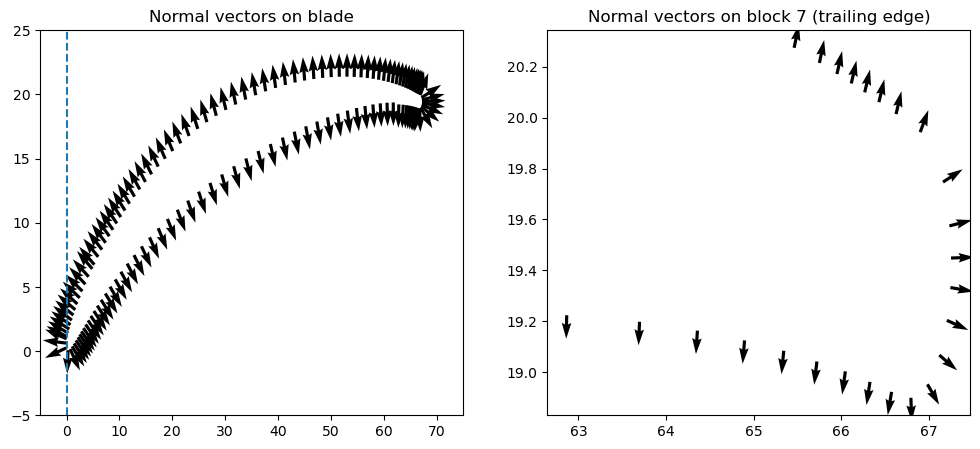

In [122]:
## Plot the wall normal vectors

pitch_blade = pp_OGV_RANS.y[6][-1][0] - pp_OGV_RANS.y[3][0][0]

## Initalize a dictionary to store all the angles of vectors in degrees
deg_dict={}

## Moderate the density and size of vectors
stride_i = 2  
size_factor = 1

## Create two subplots
fig, axes = plt.subplots(1,2, figsize = (12,5)) ## 1 row, 2 columns

for i in [3,4,6,7]:
    x_i = pp_OGV_RANS.x[i][:,0].copy()  ## .copy() to prevent contaminating the original data
    y_i = pp_OGV_RANS.y[i][:,0].copy()
    nx_i = vec_nx[i]
    ny_i = vec_ny[i]
    
    ## Lower density of vectors at the leading and trailing edge
    if i==3 or i==7:
        stride_i *= 1
        stride_i = int(stride_i)
    
    ## Decide the density of vectors to be plotted
    x_sub_i = x_i[::stride_i]
    y_sub_i = y_i[::stride_i]
    nx_i = nx_i[::stride_i]
    ny_i = ny_i[::stride_i]
    
    ## Displace block 6 to better visualize the blade
    if i==6:
        y_sub_i -= pitch_blade
    
    ## Adjust vector size
    nx_i *= size_factor
    ny_i *= size_factor
    
    ## Calculate the angle of the normal vectors in degree
    deg_dict[i] = np.rad2deg(np.arctan(np.array(ny_i)/np.array(nx_i)))
    
    ## Store the vector plot for each iteration 
    axes[0].quiver(x_sub_i, y_sub_i, nx_i, ny_i)
    
    if i == 7:
        axes[1].quiver(x_sub_i,y_sub_i,nx_i,ny_i)

        
axes[0].set_title('Normal vectors on blade')
axes[0].set_xlim([-5,75])
axes[0].set_ylim([-5,25])
axes[0].axvline(x=0, linestyle = '--')

axes[1].set_title('Normal vectors on block 7 (trailing edge)')

#plt.title('Normal vectors')
#plt.xlim([-5,75])
#plt.ylim([-5,25])
#plt.axvline(x=0, linestyle='--')

/tmp/ipykernel_11042/1039238596.py:35: RuntimeWarning: invalid value encountered in sqrt
  Mis_i = (((inlet_max_pres_tot/p_i)**((gamma-1)/gamma)-1)*(2/(gamma-1)))**0.5


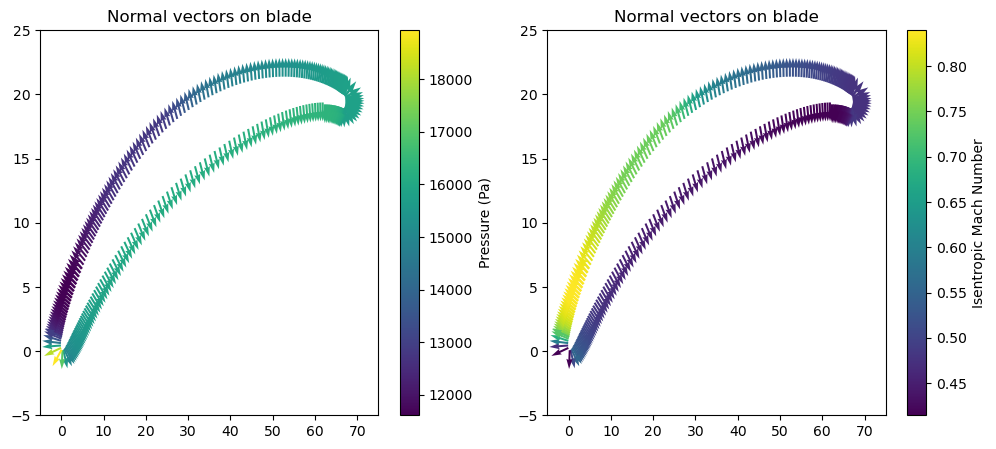

In [123]:
## Plot the wall normal vectors with a pressure colour map

pitch_blade = pp_OGV_RANS.y[6][-1][0] - pp_OGV_RANS.y[3][0][0]

gamma = 1.4       ## For isentropic relations
vmin_pres=[]
vmax_pres=[]
vmin_mis=[]
vmax_mis=[]

## Moderate the density and size of vectors
stride_i = 1  
size_factor = 1

fig, axes = plt.subplots(1,2,figsize = (12,5))  ## 1 row 2 columns

quiver_pres_plots = []
quiver_Mis_plots = []

for i in [3,4,6,7]:
    x_i = pp_OGV_RANS.x[i][:,0].copy()  ## .copy() to prevent contaminating the original data
    y_i = pp_OGV_RANS.y[i][:,0].copy()  
    nx_i = vec_nx[i]
    ny_i = vec_ny[i]
    p_i = pp_OGV_RANS._stats1[i]['p'][:,0].copy()
    
    
    ## Decide the density of vectors to be plotted
    x_sub_i = x_i[::stride_i]
    y_sub_i = y_i[::stride_i]
    nx_i = nx_i[::stride_i]
    ny_i = ny_i[::stride_i]
    p_i = p_i[::stride_i]
    
    Mis_i = (((inlet_max_pres_tot/p_i)**((gamma-1)/gamma)-1)*(2/(gamma-1)))**0.5
    
    vmin_pres.append(p_i.min())
    vmax_pres.append(p_i.max())
    
    vmin_mis.append(Mis_i.min())
    vmax_mis.append(Mis_i.max())
    
    if i==6:
        y_sub_i -= pitch_blade
    
    ## Adjust vector size
    nx_i *= size_factor
    ny_i *= size_factor
    
    ## Store the vector plot for each iteration 
    quiver_pres_plot= axes[0].quiver(x_sub_i, y_sub_i, nx_i, ny_i,p_i
              ,cmap=plt.cm.viridis)
    
    quiver_Mis_plot = axes[1].quiver(x_sub_i,y_sub_i,nx_i,ny_i,Mis_i
                                     ,cmap=plt.cm.viridis)
    
    quiver_pres_plots.append(quiver_pres_plot)
    quiver_Mis_plots.append(quiver_Mis_plot)
    

axes[0].set_title('Normal vectors on blade')
axes[0].set_xlim([-5,75])
axes[0].set_ylim([-5,25])

axes[1].set_title('Normal vectors on blade')
axes[1].set_xlim([-5,75])
axes[1].set_ylim([-5,25])

vmin_pres=min(vmin_pres)
vmax_pres=max(vmax_pres)

vmin_mis=min(vmin_mis)
vmax_mis=max(vmax_mis)

#quiver_pres_plotsfig.colorbar(quiver_pres_plot, ax=axes[0], label='Pressure (Pa)')
#fig.colorbar(quiver_Mis_plot, ax=axes[1], label='Isentropic Mach Number')

# Set the color limits on the quiver plots
for quiver_plot in quiver_pres_plots:
    quiver_plot.set_clim(vmin_pres, vmax_pres)

for quiver_plot in quiver_Mis_plots:
    quiver_plot.set_clim(vmin_mis, vmax_mis)
    
## Add colorbars for each quiver plot with specified limits
colourbar_pres = fig.colorbar(quiver_pres_plots[-1], ax=axes[0], label='Pressure (Pa)')
colourbar_mis = fig.colorbar(quiver_Mis_plots[-1], ax=axes[1], label='Isentropic Mach Number')

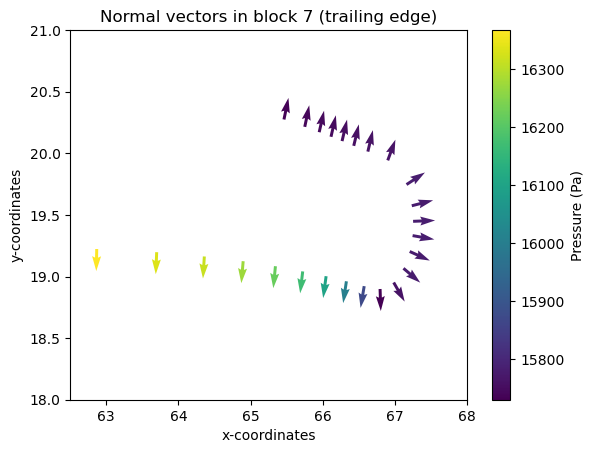

In [124]:
## Plot the wall normal vectors with a pressure colour map

pitch_blade = pp_OGV_RANS.y[6][-1][0] - pp_OGV_RANS.y[3][0][0]

## Moderate the density and size of vectors
stride_i = 2  
size_factor = 1


for i in [7]:
    x_i = pp_OGV_RANS.x[i][:,0].copy()  ## .copy() to prevent contaminating the original data
    y_i = pp_OGV_RANS.y[i][:,0].copy()
    nx_i = vec_nx[i]
    ny_i = vec_ny[i]
    p_i = pp_OGV_RANS._stats1[i]['p'][:,0].copy()
    
    ## Decide the density of vectors to be plotted
    x_sub_i = x_i[::stride_i]
    y_sub_i = y_i[::stride_i]
    nx_i = nx_i[::stride_i]
    ny_i = ny_i[::stride_i]
    p_i = p_i[::stride_i]
    
    ## Adjust vector size
    nx_i *= size_factor
    ny_i *= size_factor
    
    ## Store the vector plot for each iteration 
    quiver_plot= plt.quiver(x_sub_i, y_sub_i, nx_i, ny_i,p_i
              ,cmap=plt.cm.viridis,
              clim=(p_i.min(),p_i.max()))   ###15780


        
plt.title('Normal vectors in block 7 (trailing edge)')
plt.xlabel('x-coordinates')
plt.ylabel('y-coordinates')
plt.xlim([62.5,68])
plt.ylim([18,21])
plt.colorbar(quiver_plot, label='Pressure (Pa)')


In [125]:
print(vec_nx[7])

[ 0.20370782  0.20238816  0.20396163  0.21283182  0.22092212  0.22188093
  0.22085345  0.22180082  0.22723359  0.23157193  0.23201391  0.23355127
  0.22921122  0.22781559  0.34660319  0.60649736  0.83676578  0.9326175
  0.96883339  0.99077246  0.99921411  0.9983864   0.98494042  0.9566454
  0.91161297  0.84705044  0.76095078  0.65256628  0.49837135  0.27294455
  0.03354221 -0.11828219 -0.16491038 -0.15912462 -0.14777264 -0.14711179
 -0.13472963 -0.11712717 -0.11620794 -0.11229753 -0.09762291 -0.09083272
 -0.08386098 -0.07109516 -0.06247509 -0.05329243 -0.04156881 -0.0313862
 -0.02091805 -0.00612859]


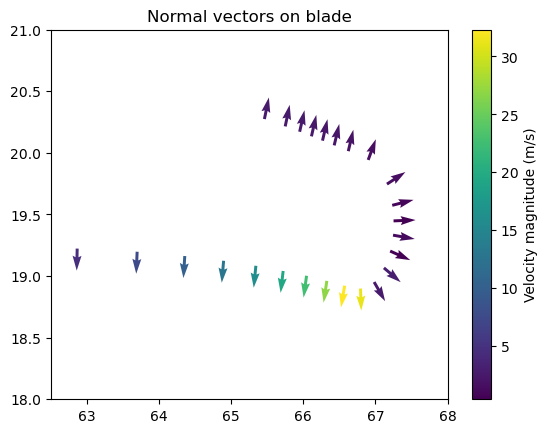

In [126]:
## Plot the wall normal vectors with a pressure colour map

pitch_blade = pp_OGV_RANS.y[6][-1][0] - pp_OGV_RANS.y[3][0][0]

## Moderate the density and size of vectors
stride_i = 2  
size_factor = 1


for i in [7]:
    x_i = pp_OGV_RANS.x[i][:,0].copy()  ## .copy() to prevent contaminating the original data
    y_i = pp_OGV_RANS.y[i][:,0].copy()
    nx_i = vec_nx[i]
    ny_i = vec_ny[i]
    u_i = pp_OGV_RANS._stats1[i]['u'][:,1].copy()
    v_i = pp_OGV_RANS._stats1[i]['v'][:,1].copy()
    w_i = pp_OGV_RANS._stats1[i]['w'][:,1].copy()
    
    vel_i = (u_i**2+v_i**2+w_i**2)**0.5
    
    ## Decide the density of vectors to be plotted
    x_sub_i = x_i[::stride_i]
    y_sub_i = y_i[::stride_i]
    nx_i = nx_i[::stride_i]
    ny_i = ny_i[::stride_i]
    vel_i = vel_i[::stride_i]
    
    ## Adjust vector size
    nx_i *= size_factor
    ny_i *= size_factor
    
    ## Store the vector plot for each iteration 
    quiver_plot= plt.quiver(x_sub_i, y_sub_i, nx_i, ny_i,vel_i
              ,cmap=plt.cm.viridis,
              clim=(vel_i.min(),vel_i.max()))   


        
plt.title('Normal vectors on blade')
plt.xlim([62.5,68])
plt.ylim([18,21])
plt.colorbar(quiver_plot, label='Velocity magnitude (m/s)')


### Calculating the boundary layer thickness 

In [127]:
## Boundary layer thickness for each block at each i position
bl_displacement = {}
bl_momentum = {}

nan_counter = 0

for block in [3,4,6,7]:
    bl_displacement[block]=[]
    bl_momentum[block]=[]
    
    for i in range(num_x_wall[block]):
        
        ## Set up a flag to allow skipping one i iteration if a NaN is found
        skip_i = False
        
        ## Obtain the freestream velocity and density at each i position for each wall block
        vel_infty = vel_infty_n[block][i]
        rho_infty = rho_infty_n[block][i]
        
        ## Numerical integration to obtain the boundary layer thickness (named delta in the loop)
        delta_displacement = 0
        delta_momentum = 0
        for j in range(j_infty_n[block][i]-1):
            
            ## Evaluate the field values along the normal vectors before reaching freestream
            rho1 = rho_interpolator(x_interp_normal[block][i][j], y_interp_normal[block][i][j])
            vel1 = vel_interpolator(x_interp_normal[block][i][j], y_interp_normal[block][i][j])          
            rho2 = rho_interpolator(x_interp_normal[block][i][j+1], y_interp_normal[block][i][j+1])
            vel2 = vel_interpolator(x_interp_normal[block][i][j+1], y_interp_normal[block][i][j+1])
            
            #print(f"block {block},i={i},j={j}")
            
            #print(f"rho1: {rho1}, rho2: {rho2}, vel1: {vel1}, vel2: {vel2}")
            
            dist = ((x_interp_normal[block][i][j+1] - x_interp_normal[block][i][j])**2 + (y_interp_normal[block][i][j+1] - y_interp_normal[block][i][j])**2)**0.5 
            
            ## Arguments for displacement thickness
            arg1 = 1 - (rho1*vel1)/(rho_infty*vel_infty)
            arg2 = 1 - (rho2*vel2)/(rho_infty*vel_infty)
            
            ## Arguments for momentum thickness
            arg3 = (rho1*vel1)/(rho_infty*vel_infty) * (1 - vel1/vel_infty)
            arg4 = (rho2*vel2)/(rho_infty*vel_infty) * (1 - vel2/vel_infty)
            
            ## Skip to next iteration if nan is found to prevent contamination of the values stored
            if np.isnan(arg1) or np.isnan(arg2) or np.isnan(arg3) or np.isnan(arg4):
                print(f"Nan detected at block: {block}, i:{i}, j:{j} -> skipping to next iteration")
                nan_counter += 1
                skip_i = True
                break
            
            ## Numerical integration
            delta_displacement += (arg1+arg2)/2 * dist
            delta_momentum += (arg3+arg4)/2 * dist
            #print(f"block: {block}, i: {i}, j: {j}, arg1: {arg1:.2f},arg2: {arg2:.2f}, delta_disp: {delta_displacement:.3f}, delta_momentum: {delta_momentum:.3f}")
            
        if skip_i:
            continue
            
        bl_displacement[block].append(delta_displacement)
        bl_momentum[block].append(delta_momentum)

print(f"Total NaN count is {nan_counter}")

Nan detected at block: 6, i:99, j:0 -> skipping to next iteration
Nan detected at block: 7, i:20, j:0 -> skipping to next iteration
Total NaN count is 2


### Visualizing the boundary layer

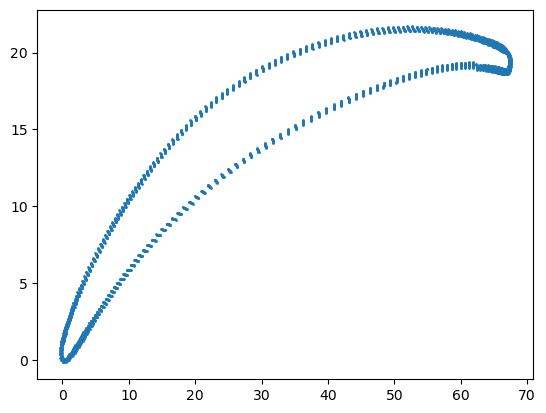

In [128]:
x_wall_global = []
y_wall_global = []

hi = 10

#pitch_blade = pp_OGV_RANS.y[6][-1][0] - pp_OGV_RANS.y[3][0][0] +0.1
pitch_blade = pp_OGV_RANS.y[6][-1][0] - pp_OGV_RANS.y[3][0][0]

for block in [3,4,6,7]:
    for i in range(pp_OGV_RANS.x[block].shape[0]):
        for j in range(hi):
            x_wall = pp_OGV_RANS.x[block][i,j]
            y_wall = pp_OGV_RANS.y[block][i,j]
            
            if block == 6:
                y_wall -= pitch_blade
        
            x_wall_global.append(x_wall)
            y_wall_global.append(y_wall)

        
plt.scatter(x_wall_global,y_wall_global,s=1)

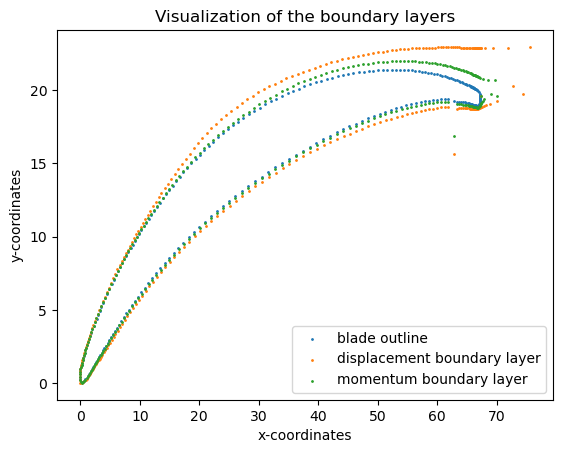

In [129]:
xtip_disp_global = []
ytip_disp_global = []
xtip_mome_global = []
ytip_mome_global = []

x_wall_global = []
y_wall_global = []

pitch_blade = pp_OGV_RANS.y[6][-1][0] - pp_OGV_RANS.y[3][0][0]

for block in [3,4,6,7]:
    for i in range(len(bl_displacement[block])):
        
        x_wall = pp_OGV_RANS.x[block][i,0]
        y_wall = pp_OGV_RANS.y[block][i,0]
         
        xtip_disp = pp_OGV_RANS.x[block][i,0] + vec_nx[block][i]*bl_displacement[block][i]
        ytip_disp = pp_OGV_RANS.y[block][i,0] + vec_ny[block][i]*bl_displacement[block][i]
            
        xtip_mome = pp_OGV_RANS.x[block][i,0] + vec_nx[block][i]*bl_momentum[block][i]
        ytip_mome = pp_OGV_RANS.y[block][i,0] + vec_ny[block][i]*bl_momentum[block][i]
        
        if block == 6:
            y_wall = y_wall - pitch_blade 
            ytip_disp = ytip_disp - pitch_blade
            ytip_mome = ytip_mome - pitch_blade
        
        x_wall_global.append(x_wall)
        y_wall_global.append(y_wall)
        xtip_disp_global.append(xtip_disp)
        ytip_disp_global.append(ytip_disp)
        xtip_mome_global.append(xtip_mome)
        ytip_mome_global.append(ytip_mome)

        
plt.scatter(x_wall_global,y_wall_global,s=1, label = 'blade outline')
plt.scatter(xtip_disp_global,ytip_disp_global,s=1, label = 'displacement boundary layer')
plt.scatter(xtip_mome_global,ytip_mome_global,s=1, label = 'momentum boundary layer')

#plt.plot(x_wall_global,y_wall_global)
#plt.plot(xtip_disp_global,ytip_disp_global)
#plt.plot(xtip_mome_global,ytip_mome_global)

plt.xlabel('x-coordinates')
plt.ylabel('y-coordinates')
plt.title('Visualization of the boundary layers')
plt.legend()

Text(0.5, 0, 'indices')

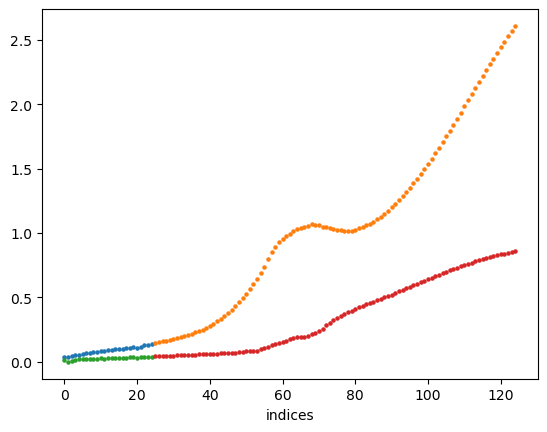

In [130]:
plt.scatter(range(len(bl_displacement[3])),bl_displacement[3],s=5)
plt.scatter(range(len(bl_displacement[3]),len(bl_displacement[3])+len(bl_displacement[4])),bl_displacement[4],s=5)
plt.scatter(range(len(bl_momentum[3])),bl_momentum[3],s=5)
plt.scatter(range(len(bl_momentum[3]),len(bl_momentum[3])+len(bl_momentum[4])),bl_momentum[4],s=5)

plt.xlabel('indices')

Text(0.5, 0, 'indices')

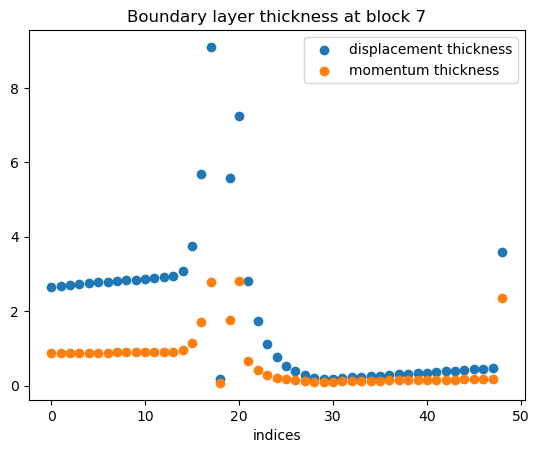

In [131]:
plt.scatter(range(len(bl_displacement[7])),bl_displacement[7],label='displacement thickness')
plt.scatter(range(len(bl_momentum[7])),bl_momentum[7], label = 'momentum thickness')
plt.title('Boundary layer thickness at block 7')
plt.legend()
plt.xlabel('indices')

Text(0.5, 0, 'indices')

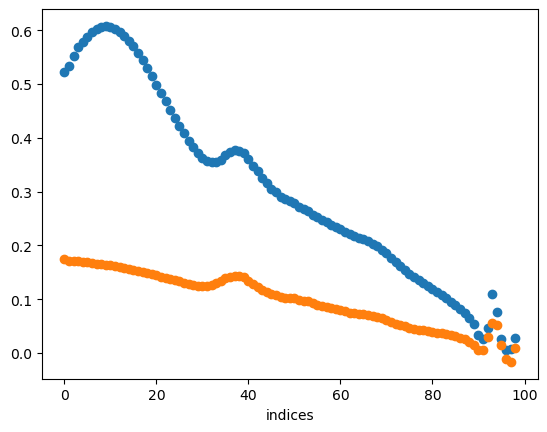

In [132]:
plt.scatter(range(len(bl_displacement[6])),bl_displacement[6])
plt.scatter(range(len(bl_momentum[6])),bl_momentum[6])
plt.xlabel('indices')

### Denton Decomposition 

In [133]:
## "Loss Mechanisms in Turbomachines" by J.D. Denton in 1993 
## Equation 26 and Equation 30

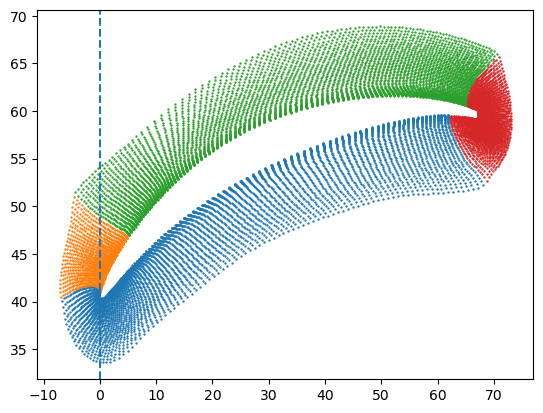

In [134]:
size = 0.5

#for i in [2,5,6,9]:
for i in [6]:
    x_i=pp_OGV_RANS.x[i]
    y_i=pp_OGV_RANS.y[i]
    x_i_flat = x_i.flatten()
    y_i_flat = y_i.flatten()
    plt.scatter(x_i_flat,y_i_flat,s=size)
    
for i in [3,4,7]:
    x_i=pp_OGV_RANS.x[i]
    y_i=pp_OGV_RANS.y[i]
    x_i_flat = x_i.flatten()
    y_i_flat = y_i.flatten() + pp_OGV_RANS.y[6][-1][0] - pp_OGV_RANS.y[3][0][0] 
    plt.scatter(x_i_flat,y_i_flat,s=size)
    
plt.axvline(x=0, linestyle='--')

In [135]:
print(np.rad2deg(math.atan(abs(vec_ny[7][1])/abs(vec_nx[7][1]))))

78.32335273657196


In [136]:
## Calculate p_refDenton
p_refDenton_list = []

i=0

while True:
    p_refDenton_list.append(pp_OGV_RANS._stats1[7]['p'][i,0])
    print(f"angle is {np.rad2deg(math.atan(abs(vec_ny[7][i])/abs(vec_nx[7][i])))}")
    if abs(vec_ny[7][i])/abs(vec_nx[7][i]) < math.tan(math.pi/4):
        break
    i+=1

p_refDenton = np.mean(p_refDenton_list)
print(f"p_refDenton is {p_refDenton}")

angle is 78.24613372592438
angle is 78.32335273657196
angle is 78.23127924096879
angle is 77.71164406279189
angle is 77.2368007522776
angle is 77.18046689658509
angle is 77.24083484689504
angle is 77.18517400535504
angle is 76.86574389026116
angle is 76.61036464392699
angle is 76.58433173790334
angle is 76.49375937356287
angle is 76.74936267568616
angle is 76.83149953304907
angle is 69.72030864008124
angle is 52.663331766094295
angle is 33.19984703791825
p_refDenton is 15754.225843391723


In [137]:
## Calculate back pressure pb

pb_list = []

for i in range(pp_OGV_RANS.nx[7]):
    if abs(vec_ny[7][i])/abs(vec_nx[7][i]) < math.tan(math.pi/4):
        pb_list.append(pp_OGV_RANS._stats1[7]['p'][i,0])
        
#print(pb_list)

pb = np.mean(pb_list)
print(pb)

15780.507571682268


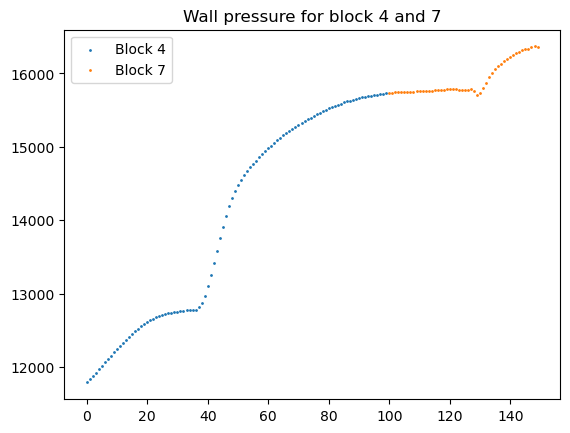

In [138]:
plt.scatter(range(len(pp_OGV_RANS._stats1[4]['p'][:,0])),pp_OGV_RANS._stats1[4]['p'][:,0],s=1,label='Block 4')
plt.scatter(range(len(pp_OGV_RANS._stats1[4]['p'][:,0]),len(pp_OGV_RANS._stats1[4]['p'][:,0])+len(pp_OGV_RANS._stats1[7]['p'][:,0])),pp_OGV_RANS._stats1[7]['p'][:,0],s=1,label = 'Block 7')

plt.title('Wall pressure for block 4 and 7')
plt.legend()

In [139]:
smallest_two = sorted(pp_OGV_RANS._stats1[7]['p'][:,0])[:2]

pb_alt = np.mean(smallest_two)

In [140]:
## Calculate Cpb

vel_refDenton = (vel_infty_n[7][0])

Cpb = (pb_alt - p_refDenton)/(0.5*pp_OGV_RANS.dict_info['Roref']*vel_refDenton**2)

print(Cpb)

-0.013066160763678796


In [141]:
## Calculate t (blade thickness)
y_trail_list = []

for i in range(pp_OGV_RANS.nx[7]):
    if abs(vec_ny[7][i])/abs(vec_nx[7][i]) < math.tan(math.pi/4):
        y_trail_list.append(pp_OGV_RANS.y[7][i,0])
        
trail_thickness = max(y_trail_list) - min(y_trail_list)
print(trail_thickness)

0.6800514717306996


In [142]:
## Calculate w (throat width)

y_upper = np.min(pp_OGV_RANS.y[7][:,0]) + pitch_blade

w = np.min(y_upper - pp_OGV_RANS.y[4][:,0]) 

w = w + trail_thickness

print(w/pitch_blade)

0.955139379757928


In [143]:
## Extract boundary layer thickness at trailing edge

i=0

while True:
    bl_disp_trail = bl_displacement[7][i]
    bl_mome_trail = bl_momentum[7][i]
    
    if abs(vec_ny[7][i])/abs(vec_nx[7][i]) < math.tan(math.pi/4):
        break
    
    i+=1
    
print(bl_disp_trail)
print(bl_mome_trail)

5.696590710279004
1.71924929902555


In [68]:
term1 = -Cpb*trail_thickness/w  ## Low base pressure
term2 = 2*bl_mome_trail/w       ## Boundary layer loss
term3 = ((bl_disp_trail + trail_thickness)/w)**2    ##Flow blocade due to trailing edge and displacement thickness
#term4 = (bl_disp_trail**2 + 2*trail_thickness*bl_disp_trail)/w**2  ## Loss due to separation 

#xi = term1 + term2 + term3 + term4
xi = term1 + term2 + term3

print(term1)
print(term2)
print(term3)
#print(term4)

print(f"Low base pressure contribution: {term1/xi*100}%")
print(f"Boundary layer loss contribution contribution: {term2/xi*100}%")
print(f"Flow blocage contribution: {term3/xi*100}%")
#print(f"Flow separation contribution: {term4/xi*100}%")

0.00023116092268733775
0.08945270722176801
0.02751904571444286
Low base pressure contribution: 0.1972313785352084%
Boundary layer loss contribution contribution: 76.32293795140713%
Flow blocage contribution: 23.479830670057677%


### Pressure Distribution on Airfoil

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


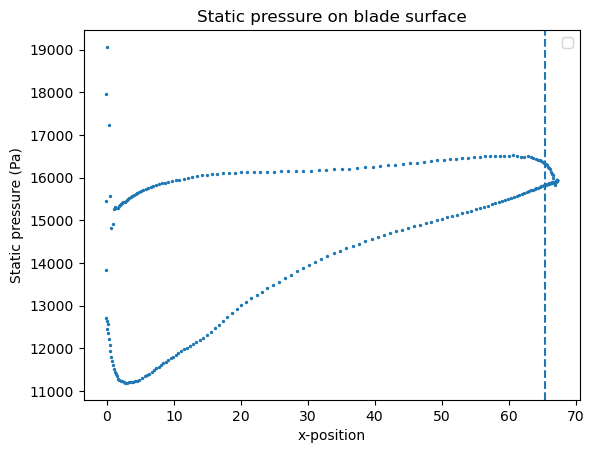

In [154]:
pres_wall_list = []
x_list = []

for i in [3,4,6,7]:
    new_pres_value = pp_OGV_RANS._stats1[i]['p'][:,0]
    pres_wall_list.append(new_pres_value)
    
    new_x_value = pp_OGV_RANS.x[i][:,0]
    x_list.append(new_x_value)

    
pres_wall = np.concatenate(pres_wall_list)
x_wall = np.concatenate(x_list)

plt.scatter(x_wall,pres_wall,s=2,label = "")
plt.title('Static pressure on blade surface')
plt.ylabel('Static pressure (Pa)')
plt.xlabel('x-position')
plt.legend()
plt.axvline(x=pp_OGV_RANS.x[7][0,0], linestyle='--')
plt.show()

### Isentropic Mach Number

In [187]:
#Convention is j being the normal vector from wall and i being the tangent vector along wall
#If thumb is x and middle finger is y, then right hand rule 

In [188]:
pres_wall_list = []
x_list = []

for i in [3,4,7,6]:
    new_pres_value = pp_OGV_RANS._stats1[i]['p'][:,0]
    pres_wall_list.append(new_pres_value)
    
    new_x_value = pp_OGV_RANS.x[i][:,0]
    x_list.append(new_x_value)

    
pres_wall = np.concatenate(pres_wall_list)
x_wall = np.concatenate(x_list)

In [189]:
Mach_is = np.sqrt(((inlet_max_pres_tot/pres_wall)**(0.4/1.4)-1)*5)
print(pres_wall.max())

19060.693125770005


/tmp/ipykernel_34065/972521627.py:1: RuntimeWarning: invalid value encountered in sqrt
  Mach_is = np.sqrt(((inlet_max_pres_tot/pres_wall)**(0.4/1.4)-1)*5)


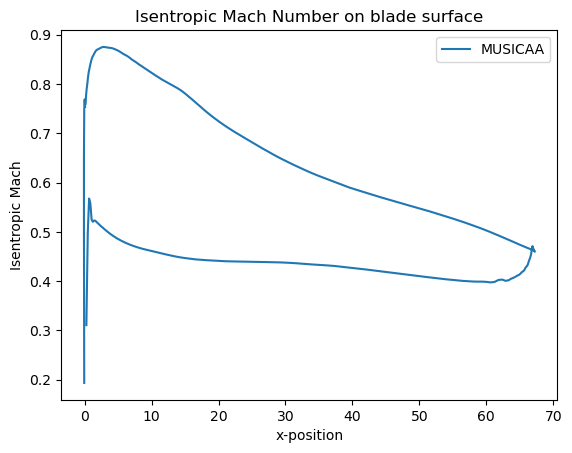

In [190]:
plt.plot(x_wall,Mach_is,label = "MUSICAA")
plt.title('Isentropic Mach Number on blade surface')
plt.ylabel('Isentropic Mach')
plt.xlabel('x-position')
plt.legend()
plt.show()

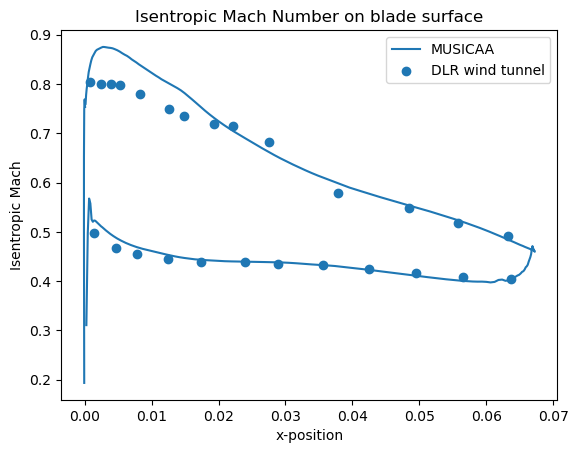

In [192]:
##Import and process DLR wind tunnel data
file_path_DLR = '/home/johnson/Desktop/Collective_Results/LRN-OGV/Wind_tunnel_DLR/LRN-OGV/LRN_OGV.ods'
sheet_name_DLR = 'Blade measurements'
df_DLR = pd.read_excel(file_path_DLR,sheet_name = sheet_name_DLR,usecols = ['x position','Mach_isentropic'])

##Scaling of data 
x_LE_gmsh = -0.000110126
x_TE_gmsh = 0.0672535
x_LE_MUSICAA = -0.108296
x_TE_MUSICAA = 67.25188

x_wall_scaled = x_wall/(x_TE_MUSICAA-x_LE_MUSICAA)*(x_TE_gmsh-x_LE_gmsh)

plt.plot(x_wall_scaled,Mach_is,label = "MUSICAA")
plt.scatter(df_DLR['x position'], df_DLR['Mach_isentropic'], label = "DLR wind tunnel")
plt.title('Isentropic Mach Number on blade surface')
plt.ylabel('Isentropic Mach')
plt.xlabel('x-position')
plt.legend()
plt.show()

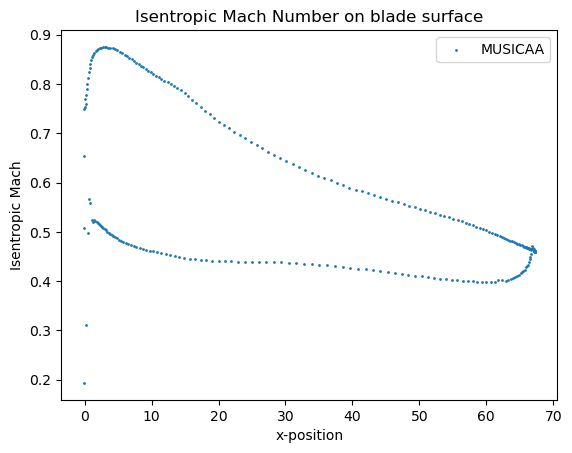

In [193]:
plt.scatter(np.array(x_wall),Mach_is,s=1,label = "MUSICAA")
plt.title('Isentropic Mach Number on blade surface')
plt.ylabel('Isentropic Mach')
plt.xlabel('x-position')
plt.legend()
plt.show()

In [195]:
#print(Mach_is.shape)
#print(x_wall.shape)

df_Mach_is = pd.DataFrame({
    'Mach_isentropic': Mach_is,
    'x position': x_wall
})

## Export the DataFrame to an Excel file
#export_directory = '/home/johnson/Desktop/Collective_Results/'
#file_path = os.path.join(export_directory,'Mach_isentropic_curve.xlsx')

#df_Mach_is.to_excel(file_path, index=False)

#print("Data exported to 'Mach_isentropic_curve.xlsx'")